## Drive & imports

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# Set seed for reproducibility
SEED = 42

# Import necessary libraries
import os
from datetime import datetime


# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
from PIL import Image
import os
import cv2
import numpy as np
import glob
import json

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch, gc
torch.manual_seed(SEED)
from torch import nn
from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
import torchvision
from torchvision.transforms import v2 as transforms
from torch.utils.data import TensorDataset, DataLoader
from torchvision.datasets import OxfordIIITPet
from torchvision.transforms import InterpolationMode
!pip install torchview
from torchview import draw_graph
import torch.optim as optim


# Configurazione di TensorBoard e directory
logs_dir = "tensorboard"
!pkill -f tensorboard
%load_ext tensorboard
!mkdir -p models

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import requests
from io import BytesIO
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.gridspec as gridspec


# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

PyTorch version: 2.9.0+cu126
Device: cuda


In [ ]:
from pathlib import Path
import shutil
import zipfile
from google.colab import files

## Prepare classification images

columns: ['filename', 'class_index']
rows: 1503

✅ Saved GT-masked images: 1503 in /content/drive/MyDrive/PROGETTO AI/TASK2_NEW/TASK2_classificationInput_GT
mapping csv: /content/drive/MyDrive/PROGETTO AI/TASK2_NEW/TASK2_classificationInput_GT/masked_mapping_GT.csv


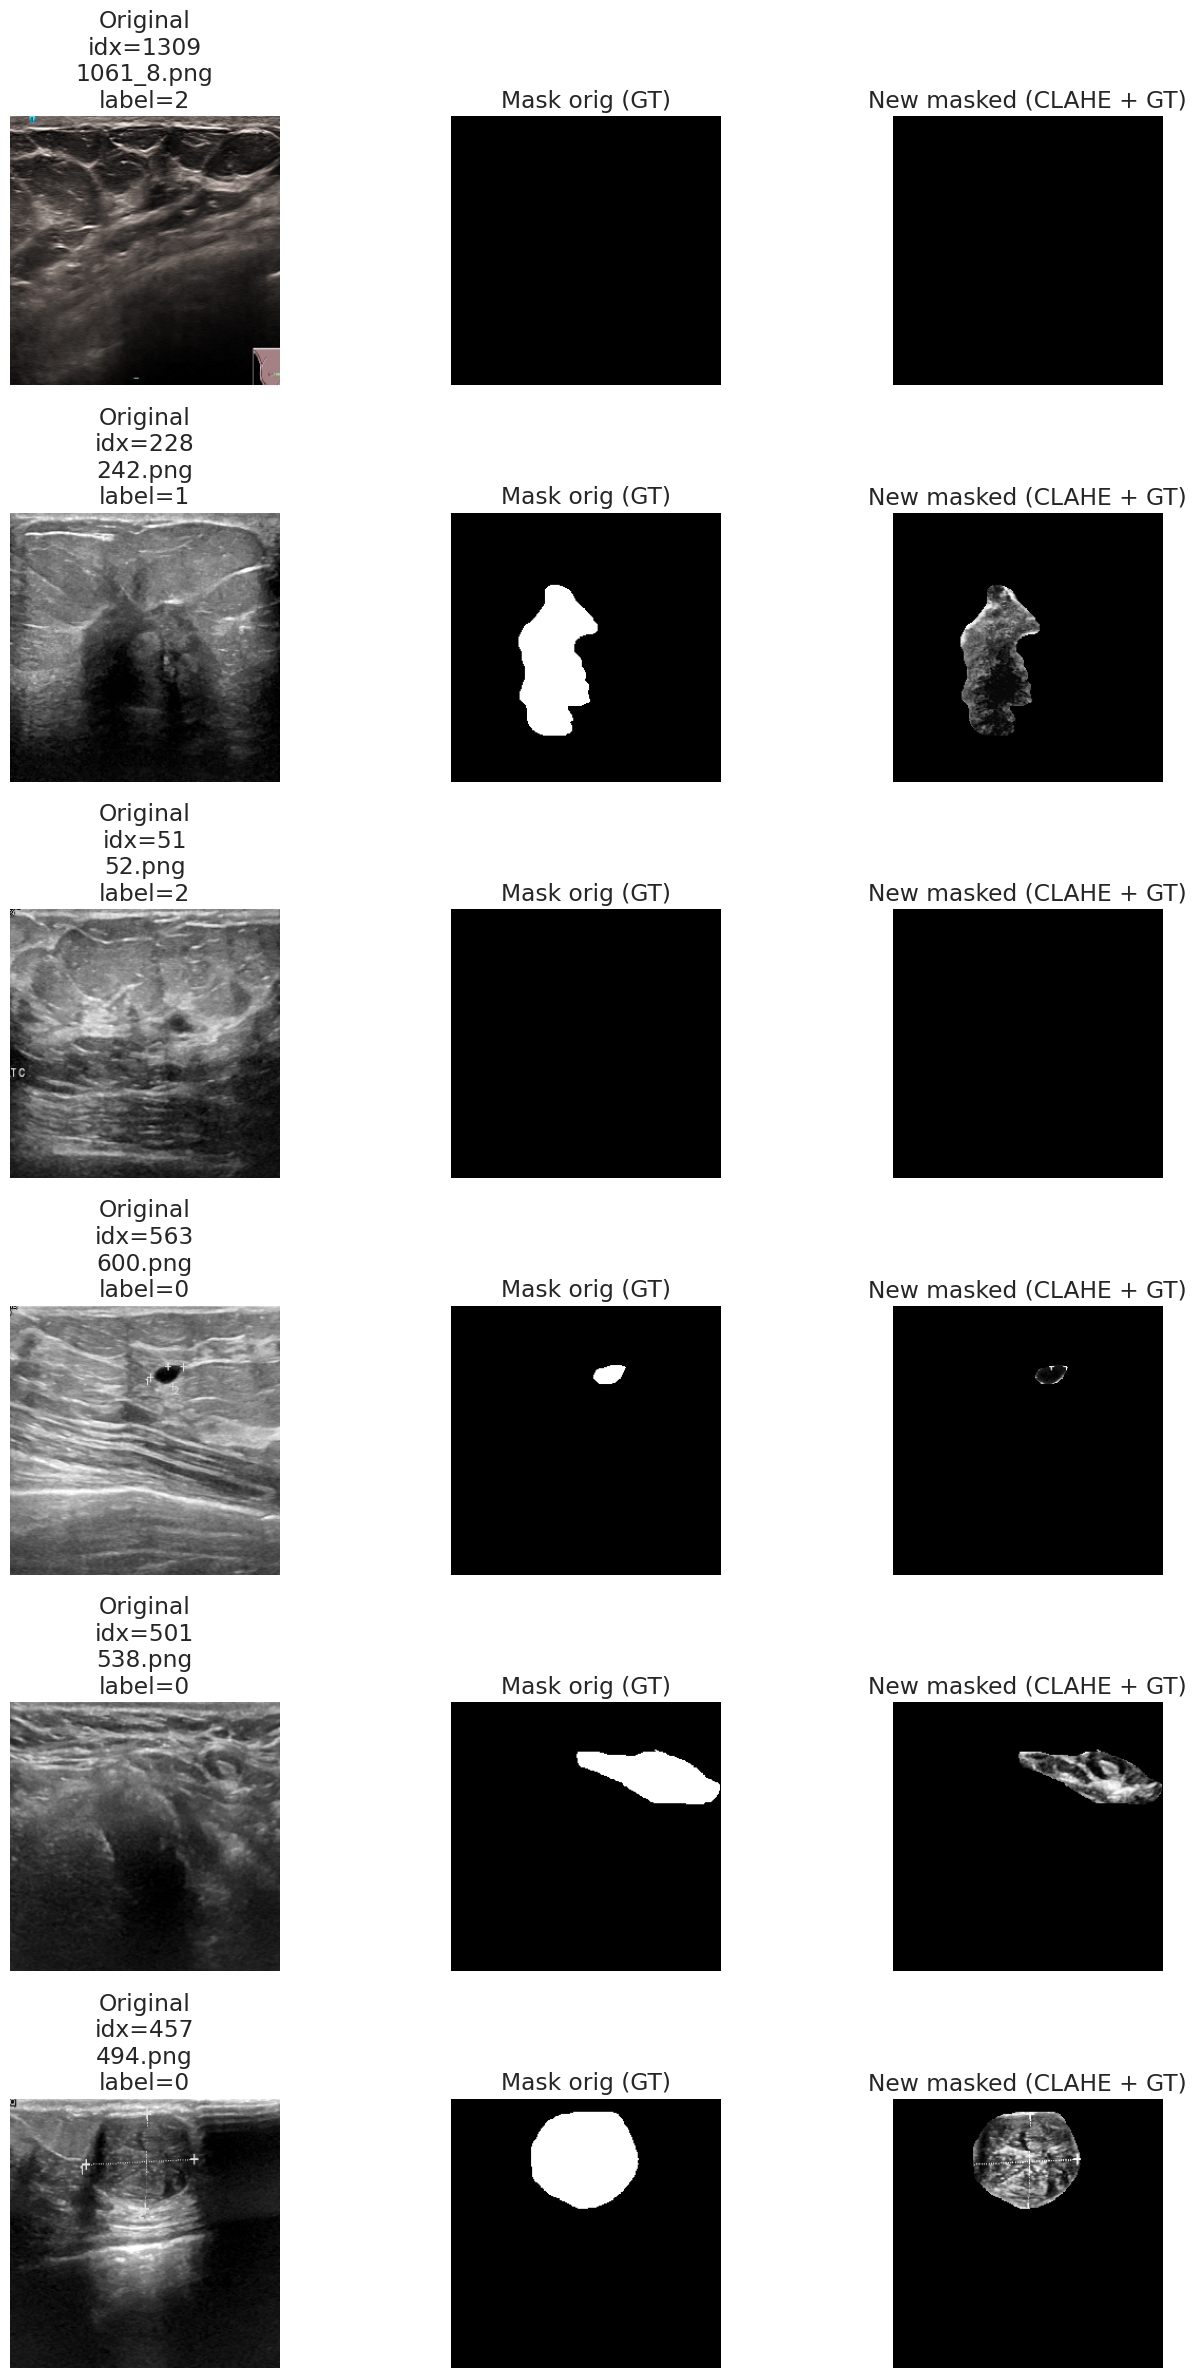

In [ ]:
# =========================================================
# Overlay con MASCHERE ORIGINALI (GT) + CLAHE
# =========================================================

import os
import pandas as pd
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import random

LABELS_CSV   = "/content/drive/MyDrive/PROGETTO AI/DATA RESIZED/labels.csv"                    # labels dataset originale
ORIG_IMG_DIR = Path("/content/drive/MyDrive/PROGETTO AI/DATA RESIZED/images")                  # immagini originali
ORIG_MASK_DIR= Path("/content/drive/MyDrive/PROGETTO AI/DATA RESIZED/masks")                   # maschere originali (GT)

OUT_DIR      = Path("/content/drive/MyDrive/PROGETTO AI/TASK2_NEW/TASK2_classificationInput_GT")   # output immagini mascherate (GT)
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# labels.csv
# ---------------------------------------------------------
df = pd.read_csv(LABELS_CSV)
print("columns:", df.columns.tolist())
print("rows:", len(df))

# ---------------------------------------------------------
# CLAHE + masking
# ---------------------------------------------------------
def clahe_single(img_rgb_uint8):
    """
    img_rgb_uint8: (H,W,3) uint8 RGB
    return: (H,W) uint8 (grayscale + CLAHE)
    """
    gray = cv2.cvtColor(img_rgb_uint8, cv2.COLOR_RGB2GRAY)
    clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8, 8))
    return clahe.apply(gray)

def apply_binary_mask(grayscale_uint8, mask_uint8):
    """
    Pixel neri restano neri, pixel bianchi diventano quelli dell'immagine (grayscale_clahe).
    -> output = grayscale * (mask>0)
    """
    m = (mask_uint8 > 0).astype(np.uint8)  # 0/1
    return (grayscale_uint8 * m).astype(np.uint8)

# ---------------------------------------------------------
# Crea e salva immagini mascherate (GT)
# ---------------------------------------------------------
saved_rows = []

for idx, row in df.iterrows():
    fname = str(row["filename"])
    label = int(row["class_index"])

    img_path = ORIG_IMG_DIR / fname
    msk_path = ORIG_MASK_DIR / fname

    if not img_path.exists() or not msk_path.exists():
        print(f" Missing orig img or GT mask: idx={idx} fname={fname}")
        continue

    # Load orig image (RGB)
    img_bgr = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
    if img_bgr is None:
        print(f" cv2.imread failed image: {img_path}")
        continue
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Load GT mask
    m_orig = cv2.imread(str(msk_path), cv2.IMREAD_GRAYSCALE)
    if m_orig is None:
        print(f" cv2.imread failed mask: {msk_path}")
        continue

    # CLAHE grayscale
    img_clahe = clahe_single(img_rgb)

    if m_orig.shape != img_clahe.shape:
        print(f" Shape mismatch idx={idx}: clahe={img_clahe.shape}, gt={m_orig.shape}")
        continue

    # Apply GT mask
    masked = apply_binary_mask(img_clahe, m_orig)

    # Save as idx.png (idx = riga labels.csv)
    out_name = f"{idx}.png"
    out_path = OUT_DIR / out_name
    cv2.imwrite(str(out_path), masked)

    saved_rows.append({
        "idx": idx,
        "filename": fname,
        "class_index": label,
        "gt_mask_path": str(msk_path),
        "out_path": str(out_path),
    })

print(f"\n Saved GT-masked images: {len(saved_rows)} in {OUT_DIR}")

# salva mapping csv
map_csv = OUT_DIR / "masked_mapping_GT.csv"
pd.DataFrame(saved_rows).to_csv(map_csv, index=False)
print("mapping csv:", map_csv)

# ---------------------------------------------------------
# Print di controllo
# ---------------------------------------------------------
N_SHOW = 6
idxs = random.sample([r["idx"] for r in saved_rows], k=min(N_SHOW, len(saved_rows)))

fig, axes = plt.subplots(len(idxs), 3, figsize=(14, 4*len(idxs)))
if len(idxs) == 1:
    axes = np.array([axes])

for i, idx in enumerate(idxs):
    row = df.iloc[idx]
    fname = str(row["filename"])
    label = int(row["class_index"])

    img_path = ORIG_IMG_DIR / fname
    msk_path = ORIG_MASK_DIR / fname

    img_bgr = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    m_orig = cv2.imread(str(msk_path), cv2.IMREAD_GRAYSCALE)

    img_clahe = clahe_single(img_rgb)
    masked = apply_binary_mask(img_clahe, m_orig)

    axes[i,0].imshow(img_rgb)
    axes[i,0].set_title(f"Original\nidx={idx}\n{fname}\nlabel={label}")
    axes[i,0].axis("off")

    axes[i,1].imshow(m_orig, cmap="gray")
    axes[i,1].set_title("Mask orig (GT)")
    axes[i,1].axis("off")

    axes[i,2].imshow(masked, cmap="gray")
    axes[i,2].set_title("New masked (CLAHE + GT)")
    axes[i,2].axis("off")

plt.tight_layout()
plt.show()


In [ ]:
LABELS_CSV = "/content/drive/MyDrive/PROGETTO AI/DATA RESIZED/labels.csv"
MASKED_DIR = Path("/content/drive/MyDrive/PROGETTO AI/TASK2_NEW/TASK2_classificationInput_GT")

# =========================
# 1) Indici da labels.csv
# =========================
df = pd.read_csv(LABELS_CSV)
csv_idx = set(df.index.tolist())

print("labels.csv")
print("  rows:", len(csv_idx))
print("  idx range:", min(csv_idx), "→", max(csv_idx))

# =========================
# 2) Indici dalle immagini mascherate
# =========================
img_idx = set()

for p in MASKED_DIR.glob("*.png"):
    try:
        img_idx.add(int(p.stem))   # "1385.png" → 1385
    except ValueError:
        print("⚠️ File ignorato (non numerico):", p.name)

print("\nmasked images")
print("  images:", len(img_idx))
print("  idx range:", min(img_idx), "→", max(img_idx))

# =========================
# 3) Confronto
# =========================
missing_imgs = csv_idx - img_idx
extra_imgs   = img_idx - csv_idx

print("\n=== CHECK RESULT ===")

if not missing_imgs and not extra_imgs:
    print("✅ OK: labels.csv e immagini mascherate sono PERFETTAMENTE allineati")
else:
    print("❌ MISMATCH")

    if missing_imgs:
        print(f"  missing images for idx ({len(missing_imgs)}):",
              sorted(list(missing_imgs))[:10], "...")

    if extra_imgs:
        print(f"  extra images without label ({len(extra_imgs)}):",
              sorted(list(extra_imgs))[:10], "...")


labels.csv
  rows: 1503
  idx range: 0 → 1502

masked images
  images: 1503
  idx range: 0 → 1502

=== CHECK RESULT ===
✅ OK: labels.csv e immagini mascherate sono PERFETTAMENTE allineati


## Data loading

In [ ]:
# @title Data loading fun

def load_classification_input(
    zip_path,
    labels_csv_path,
    extract_root="/content",
    force_unzip=False,
    label_col="class_index",
    filename_col="filename",
):

    zip_path = str(zip_path)
    labels_csv_path = str(labels_csv_path)

    zip_name = os.path.splitext(os.path.basename(zip_path))[0]
    dataset_dir = Path(extract_root) / zip_name

    if force_unzip and dataset_dir.exists():
        import shutil
        shutil.rmtree(dataset_dir)

    if not dataset_dir.exists():
        print(f" Estrazione ZIP → {dataset_dir}")
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(extract_root)
    else:
        print(f"ZIP già estratto: {dataset_dir}")

    print(f"\n Dataset dir: {dataset_dir}")

    df = pd.read_csv(labels_csv_path)
    if label_col not in df.columns:
        raise ValueError(f"Manca '{label_col}' nel CSV. Colonne: {df.columns.tolist()}")
    if filename_col not in df.columns:
        raise ValueError(f"Manca '{filename_col}' nel CSV. Colonne: {df.columns.tolist()}")

    N = len(df)
    print(f"Righe CSV: {N}")

    masked_dir = dataset_dir
    print(f"Masked images dir: {masked_dir}")


    X, y, filenames = [], [], []
    missing = 0

    for idx, row in tqdm(df.iterrows(), total=N):
        img_path = masked_dir / f"{idx}.png"

        if not img_path.exists():
            print(f"Missing masked image: idx={idx}")
            missing += 1
            continue

        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is None:
            print(f"cv2.imread failed: {img_path}")
            continue

        X.append(img)
        y.append(int(row[label_col]))
        filenames.append(str(row[filename_col]))

    X = np.array(X)
    y = np.array(y)

    print("\n Classification dataset loaded")
    print("X:", X.shape, X.dtype)
    print("y:", y.shape, y.dtype)
    print("missing images:", missing)

    return X, y, filenames, df, str(masked_dir), str(dataset_dir)


In [ ]:
zip_path = "/content/drive/MyDrive/PROGETTO AI/TASK2_NEW/TASK2_classificationInput_GT.zip"
labels_csv_path = "/content/drive/MyDrive/PROGETTO AI/DATA RESIZED/labels.csv"
extract_root = "/content/drive/MyDrive/PROGETTO AI/TASK2"


X_cls, y_cls, fnames_orig, df_labels, masked_dir, extracted_dir = load_classification_input(
    zip_path=zip_path,
    labels_csv_path=labels_csv_path,
    extract_root=extract_root
)


ZIP già estratto: /content/drive/MyDrive/PROGETTO AI/TASK2/TASK2_classificationInput_GT

 Dataset dir: /content/drive/MyDrive/PROGETTO AI/TASK2/TASK2_classificationInput_GT
Righe CSV: 1503
Masked images dir: /content/drive/MyDrive/PROGETTO AI/TASK2/TASK2_classificationInput_GT


  0%|          | 0/1503 [00:00<?, ?it/s]


 Classification dataset loaded
X: (1503, 256, 256) uint8
y: (1503,) int64
missing images: 0


## Augmentation (cls)

In [ ]:
# @title Step 1) Split -> subset train/val (cls)

def get_fold_data_from_csv_cls(X, y, filenames, fold_csv_path):
    df = pd.read_csv(fold_csv_path)

    train_idx = df[df["split"] == "train"]["idx"].values.astype(int)
    val_idx   = df[df["split"] == "val"]["idx"].values.astype(int)

    X_train = X[train_idx]
    y_train = y[train_idx]
    fn_train = np.asarray(filenames)[train_idx]

    X_val = X[val_idx]
    y_val = y[val_idx]
    fn_val = np.asarray(filenames)[val_idx]

    return X_train, y_train, fn_train, X_val, y_val, fn_val


In [ ]:
# @title Step 2) Offline augmentation — CLASSIFICATION

import albumentations as A
import cv2
import numpy as np

def balance_dataset_offline_cls(X_train, y_train, filenames_train):
    print("="*80)
    print("BILANCIAMENTO DATASET OFFLINE — CLASSIFICATION")
    print("="*80)

    X_work = X_train.copy()
    filenames_arr = np.array(filenames_train)

    if X_work.dtype != np.uint8:
        print("Conversione X_train in uint8...")
        if X_work.max() <= 1.5:
            X_work = (X_work * 255).astype(np.uint8)
        else:
            X_work = X_work.astype(np.uint8)

    unique, counts = np.unique(y_train, return_counts=True)
    max_count = np.max(counts)

    print(f"Distribuzione iniziale: {dict(zip(unique, counts))}")
    print(f"Target per classe: {max_count}")

    X_bal = []
    y_bal = []
    filenames_bal = []

    elastic_transform = A.Compose([
        A.ElasticTransform(
            alpha=100,
            sigma=10,
            alpha_affine=10,
            border_mode=cv2.BORDER_CONSTANT,
            value=0,
            p=1.0
        )
    ])

    for class_id in unique:

        idxs = np.where(y_train == class_id)[0]

        X_class = X_work[idxs]
        y_class = y_train[idxs]
        fnames_class = filenames_arr[idxs]

        X_bal.extend(X_class)
        y_bal.extend(y_class)
        filenames_bal.extend(fnames_class)

        current = len(X_class)
        needed = max_count - current

        if needed > 0:
            print(f"\n> Classe {class_id}: generazione di {needed} copie sintetiche...")
            for i in range(needed):
                rand_i = np.random.randint(0, current)

                img_orig = X_class[rand_i]
                fname_orig = fnames_class[rand_i]

                aug = elastic_transform(image=img_orig)



                X_bal.append(aug["image"])
                y_bal.append(class_id)
                filenames_bal.append(f"{fname_orig}_aug_{i}")
        else:
            print(f"> Classe {class_id}: già bilanciata.")

    print("="*80)
    print(f"Dataset finale bilanciato: {len(X_bal)} campioni")

    return (
        np.array(X_bal),
        np.array(y_bal),
        np.array(filenames_bal)
    )


In [ ]:
# @title Step 3A) Online augmentation — CLASSIFICATION

import albumentations as A
import cv2

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(
        limit=5,
        border_mode=cv2.BORDER_CONSTANT,
        value=0,
        p=0.5
    ),
])

val_transform = A.Compose([])
test_transform = val_transform


In [ ]:
# @title Step 3B) Dataset — CLASSIFICATION

from torch.utils.data import Dataset
import torch
import numpy as np

class BreastUSClassificationDataset(Dataset):
    def __init__(self, images, labels, filenames=None, transform=None, channels_number=1):

        self.images = images
        self.labels = labels
        self.filenames = filenames
        self.transform = transform
        self.channels_number = channels_number

        if channels_number not in [1, 3]:
            raise ValueError(f"channels_number non supportato: {channels_number}")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # 1. Recupero dati
        img = self.images[idx]
        label = self.labels[idx]
        fname = None if self.filenames is None else str(self.filenames[idx])

        if img.dtype != np.uint8:
            if img.max() <= 1.5:
                img = (img * 255).astype(np.uint8)
            else:
                img = img.astype(np.uint8)

        # 2. Augmentation
        if self.transform:
            augmented = self.transform(image=img)
            img = augmented["image"]

        # Normalizzazione [0,255] → [0,1]
        img = img.astype("float32") / 255.0

        if img.ndim == 2:
            img = img[:, :, None]

        # Numpy HWC → Tensor CHW
        img = torch.from_numpy(img).permute(2, 0, 1)  # (1, H, W)

        # D) Se richiesto 3 canali → replica
        if self.channels_number == 3:
            img = img.repeat(3, 1, 1)  # (3, H, W)

        # E) Label
        label = torch.tensor(label, dtype=torch.long)

        return img, label, fname


In [ ]:
# @title Visualization - Offline augmentation families (CLASSIFICATION)

import matplotlib.pyplot as plt
import numpy as np
import random

def visualize_augmentation_results_cls(
    X, filenames,
    num_families=3,
    max_aug_per_family=2,
    seed=42
):

    if isinstance(filenames, np.ndarray):
        fn = filenames.astype(str).tolist()
    else:
        fn = [str(f) for f in filenames]

    # 1) trova tutte le immagini augmentate
    aug_idxs = [i for i, f in enumerate(fn) if "_aug_" in f]
    if len(aug_idxs) == 0:
        print("[INFO] Nessuna immagine augmentata trovata.")
        return

    # 2) trova i base_name unici
    base_names = sorted({fn[i].split("_aug_")[0] for i in aug_idxs})

    rng = random.Random(seed)
    chosen_bases = rng.sample(base_names, k=min(num_families, len(base_names)))

    print(f"[INFO] Visualizzo {len(chosen_bases)} famiglie (max {max_aug_per_family} copie per famiglia).")

    for base in chosen_bases:
        orig_candidates = [i for i, f in enumerate(fn) if f == base]
        orig_idx = orig_candidates[0] if len(orig_candidates) > 0 else None

        family_aug = [(i, fn[i]) for i in aug_idxs if fn[i].startswith(base + "_aug_")]

        def aug_key(item):
            try:
                return int(item[1].split("_aug_")[1])
            except Exception:
                return 10**9

        family_aug = sorted(family_aug, key=aug_key)
        family_aug_idxs = [i for i, _ in family_aug][:max_aug_per_family]

        all_indices = ([orig_idx] if orig_idx is not None else []) + family_aug_idxs
        if len(all_indices) == 0:
            continue

        n = len(all_indices)
        fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
        if n == 1:
            axes = np.array([axes])

        fig.suptitle(f"Offline Augmentation Family: {base}", fontsize=14)

        for j, idx in enumerate(all_indices):
            img = X[idx]
            if img.ndim == 3 and img.shape[-1] == 1:
                img = img.squeeze(-1)

            axes[j].imshow(img, cmap="gray")
            if orig_idx is not None and idx == orig_idx:
                axes[j].set_title("ORIG", color="green", fontweight="bold")
            else:
                axes[j].set_title(fn[idx].split(base)[-1], color="blue")
            axes[j].axis("off")

        plt.tight_layout()
        plt.show()


In [ ]:
# @title Visualization - Online augmentation (CLASSIFICATION)

import torch
import matplotlib.pyplot as plt

def visualize_one_train_batch_cls(train_loader, n_show=1):
    images, labels, _ = next(iter(train_loader))

    print("\n--- CONTROLLO BATCH TRAIN ---")
    print(f"Shape Immagini (B, C, H, W): {images.shape}")
    print(f"Shape Label: {labels.shape}")
    print(f"Range Immagine: min={images.min().item():.4f}, max={images.max().item():.4f}")

    n_show = min(n_show, images.shape[0])
    for idx in range(n_show):
        plt.figure(figsize=(4, 4))
        plt.imshow(
            images[idx].permute(1, 2, 0).squeeze().cpu().numpy(),
            cmap="gray"
        )
        plt.title(f"Train Img (label={labels[idx].item()})")
        plt.axis("off")
        plt.tight_layout()
        plt.show()


In [ ]:
# @title Wrapper per k-fold split e augmentation (offline + online) — CLASSIFICATION

def build_fold_loaders_cls(
    fold_csv_path,
    X_all, y_all, filenames_all,
    channels_number,
    batch_size=8,
    num_workers=2,
    seed=42,
    return_offline_data=False
):

    # -------------------------
    # Step 1) split -> train / val
    # -------------------------
    X_train, y_train, fn_train, \
    X_val,   y_val,   fn_val = \
        get_fold_data_from_csv_cls(
            X_all, y_all, filenames_all, fold_csv_path
        )

    # -------------------------
    # Step 2) Offline augmentation
    # -------------------------
    np.random.seed(seed)

    X_train_bal, y_train_bal, fn_train_bal = balance_dataset_offline_cls(
        X_train, y_train, fn_train
    )

    # -------------------------
    # Step 3) Online augmentation (Dataset + Loader)
    # -------------------------
    train_ds = BreastUSClassificationDataset(
        X_train_bal,
        y_train_bal,
        filenames=fn_train_bal,
        transform=train_transform,
        channels_number=channels_number
    )

    val_ds = BreastUSClassificationDataset(
        X_val,
        y_val,
        filenames=fn_val,
        transform=val_transform,
        channels_number=channels_number
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )


    if return_offline_data:
        return (
            train_loader,
            val_loader,
            X_train_bal,
            fn_train_bal
        )

    return train_loader, val_loader


# Classification models

## Funzioni comuni

In [ ]:
# @title Make model

import torch
import torch.nn as nn
import torchvision.models as models
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score, balanced_accuracy_score


def make_model(
    arch,
    channels_number,
    classes,
    device,
    model_cfg=None
):
    """
    arch: str
        - "vgg16_paper"
        - "vgg16"
    channels_number: int (1 o 3)
    classes: int
    model_cfg: dict opzionale
        {
            "unfreeze_last_block": True,
            "dropout": 0.1
        }
    """

    if model_cfg is None:
        model_cfg = {}

    arch = arch.lower()
    dropout = model_cfg.get("dropout", 0.1)
    unfreeze_last_block = model_cfg.get("unfreeze_last_block", False)

    # =========================
    # BASE MODEL
    # =========================
    model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

    # =========================
    # INPUT CHANNELS HANDLING
    # =========================
    if channels_number == 1:
        original_conv = model.features[0]
        model.features[0] = nn.Conv2d(
            in_channels=1,
            out_channels=original_conv.out_channels,
            kernel_size=original_conv.kernel_size,
            stride=original_conv.stride,
            padding=original_conv.padding
        )
        with torch.no_grad():
            model.features[0].weight[:] = original_conv.weight.mean(dim=1, keepdim=True)
            model.features[0].bias[:] = original_conv.bias

    elif channels_number == 3:
        pass
    else:
        raise ValueError(f"channels_number non supportato: {channels_number}")

    # =========================
    # HEAD
    # =========================
    if arch == "vgg16_1ch":
        in_features = model.classifier[0].in_features  # 25088
        model.classifier = nn.Sequential(
            nn.Linear(in_features, 4096),
            nn.ReLU(True),
            nn.Dropout(p=dropout),
            nn.Linear(4096, 4096),
            nn.ReLU(True),
            nn.Dropout(p=dropout),
            nn.Linear(4096, classes)
        )

    elif arch == "vgg16_3ch":
        model.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        model.classifier = nn.Sequential(
            nn.Linear(512, 512),
            nn.ReLU(True),
            nn.Dropout(p=dropout),
            nn.Linear(512, 128),
            nn.ReLU(True),
            nn.Dropout(p=dropout),
            nn.Linear(128, classes)
        )

    else:
        raise ValueError(f"Architettura non supportata: {arch}")

    # =========================
    # UNFREEZING
    # =========================
    for param in model.features.parameters():
        param.requires_grad = False

    if unfreeze_last_block:
        for layer in model.features[24:]:
            for param in layer.parameters():
                param.requires_grad = True

    for param in model.classifier.parameters():
        param.requires_grad = True

    model = model.to(device)
    return model


In [ ]:
# @title Helper functions

""" Per recuperare le cartelle """

def get_fold_paths_simple(MODELS_DIR, run_name, fold_id):
    run_dir = os.path.join(MODELS_DIR, run_name)
    fold_dir = os.path.join(run_dir, f"fold_{fold_id}")
    os.makedirs(fold_dir, exist_ok=True)
    return {
        "run_dir": run_dir,
        "fold_dir": fold_dir,
        "best_path": os.path.join(fold_dir, "best.pth"),
        "history_csv": os.path.join(fold_dir, "history.csv"),
        "metrics_json": os.path.join(fold_dir, "metrics.json"),
    }



# @title helper per ricaricare pesi
def load_best_checkpoint(model, ckpt_path, device):
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.to(device)
    return ckpt

# @title helper per creare path salvataggio pesi

def get_ckpt_paths(run_dir, fold_id):
    fold_dir = os.path.join(run_dir, f"fold_{fold_id}")
    os.makedirs(fold_dir, exist_ok=True)
    best_path = os.path.join(fold_dir, "best.pth")
    return best_path



In [ ]:
# @title confusion matrix

def plot_confusion_matrix_blue(cm, class_names=None, title="Confusion Matrix"):
    cm = np.array(cm, dtype=np.int64)
    n = cm.shape[0]

    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap="Blues")

    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    if class_names is None:
        class_names = [str(i) for i in range(n)]

    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)

    # numeri dentro le celle
    for i in range(n):
        for j in range(n):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.show()


In [ ]:
# @title plot

def plot_history_one_fold(history_df, fold_id):
    plt.figure(figsize=(10, 4))
    plt.plot(history_df["loss"], label="train_loss")
    if "val_loss" in history_df.columns:
        plt.plot(history_df["val_loss"], label="val_loss")
    plt.title(f"Fold {fold_id} — Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    if "accuracy" in history_df.columns:
        plt.figure(figsize=(10, 4))
        plt.plot(history_df["accuracy"], label="train_acc")
        if "val_accuracy" in history_df.columns:
            plt.plot(history_df["val_accuracy"], label="val_acc")
        plt.title(f"Fold {fold_id} — Accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.grid(True)
        plt.show()


In [ ]:
# @title Train one fold — CLASSIFICATION

def train_one_fold_cls(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    device,
    n_epochs=50,
    patience=10,
    save_path_best=None,
    history_csv_path=None,
    fold_id=None,
    plot_history=True,
):
    history = {
        "loss": [], "val_loss": [],
        "accuracy": [], "val_accuracy": [],
        "f1": [], "val_f1": [],
        "bal_acc": [], "val_bal_acc": []
    }

    use_val = val_loader is not None
    best_score = -float("inf")
    best_val_loss = float("inf")
    best_val_acc = None
    best_val_bal_acc = None
    val_loss_at_best = None
    epochs_no_improve = 0

    if history_csv_path is not None:
        os.makedirs(os.path.dirname(history_csv_path), exist_ok=True)
    if save_path_best is not None:
        os.makedirs(os.path.dirname(save_path_best), exist_ok=True)

    tag = f"[FOLD {fold_id}] " if fold_id is not None else ""
    print(f"{tag}Starting CLASSIFICATION training for {n_epochs} epochs")
    print(f"{'='*60}\n")

    for epoch in range(n_epochs):

        # ================= TRAIN =================
        model.train()
        train_loss = 0.0
        y_true, y_pred = [], []

        loop = tqdm(train_loader, total=len(train_loader),
                    desc=f"{tag}Epoch [{epoch+1}/{n_epochs}] [TRAIN]", leave=True)

        for imgs, labels, _ in loop:
            imgs = imgs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad(set_to_none=True)
            outputs = model(imgs)

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * imgs.size(0)

            preds = torch.argmax(outputs, dim=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

        train_loss /= len(train_loader.dataset)
        train_acc = np.mean(np.array(y_true) == np.array(y_pred))
        train_f1 = f1_score(y_true, y_pred, average="macro")
        train_bal_acc = balanced_accuracy_score(y_true, y_pred)

        # ================= VALIDATION =================
        if use_val:
            model.eval()
            val_loss = 0.0
            yv_true, yv_pred = [], []

            with torch.no_grad():
                for imgs, labels, _ in val_loader:
                    imgs = imgs.to(device)
                    labels = labels.to(device)

                    outputs = model(imgs)
                    loss = criterion(outputs, labels)

                    val_loss += loss.item() * imgs.size(0)

                    preds = torch.argmax(outputs, dim=1)
                    yv_true.extend(labels.cpu().numpy())
                    yv_pred.extend(preds.cpu().numpy())

            val_loss /= len(val_loader.dataset)
            val_acc = np.mean(np.array(yv_true) == np.array(yv_pred))
            val_f1 = f1_score(yv_true, yv_pred, average="macro")
            val_bal_acc = balanced_accuracy_score(yv_true, yv_pred)

        else:
            val_loss = val_acc = val_f1 = val_bal_acc = None

        # ================= HISTORY =================
        history["loss"].append(train_loss)
        history["accuracy"].append(train_acc)
        history["f1"].append(train_f1)
        history["bal_acc"].append(train_bal_acc)

        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_acc)
        history["val_f1"].append(val_f1)
        history["val_bal_acc"].append(val_bal_acc)

        if history_csv_path is not None:
            pd.DataFrame(history).to_csv(history_csv_path, index=False)

        # ================= SCHEDULER =================
        if scheduler is not None:
            scheduler.step(val_loss if use_val else train_loss)

        # ================= LOG =================
        print(
            f"{tag}Epoch {epoch+1}/{n_epochs} | "
            f"Train Loss {train_loss:.4f} Acc {train_acc:.3f} "
            f"F1 {train_f1:.3f} BalAcc {train_bal_acc:.3f} || "
            f"Val Loss {val_loss:.4f} Acc {val_acc:.3f} "
            f"F1 {val_f1:.3f} BalAcc {val_bal_acc:.3f}"
        )

        # ================= EARLY STOPPING (val_loss) =================
        if use_val:
            if val_loss < best_val_loss:
                best_val_loss = float(val_loss)
                best_val_acc = float(val_acc)
                epochs_no_improve = 0



                if save_path_best is not None:
                    os.makedirs(os.path.dirname(save_path_best), exist_ok=True)
                    torch.save({
                        "epoch": epoch + 1,
                        "model_state_dict": model.state_dict(),
                        "optimizer_state_dict": optimizer.state_dict(),
                        "train_loss": float(train_loss),
                        "val_loss": float(val_loss),
                        "train_acc": float(train_acc),
                        "val_acc": float(val_acc),
                        "best_val_loss": float(best_val_loss),
                    }, save_path_best)

                print(f"{tag}  💾 Saved new best model (Val Loss {best_val_loss:.4f})")
            else:
                epochs_no_improve += 1
                print(f"{tag}  No improvement for {epochs_no_improve}/{patience}")

            print(f"{'─'*60}\n")

        if epochs_no_improve >= patience:
            print(f"{tag}🛑 Early stopping triggered after {epoch+1} epochs!")
            print(f"{tag}Best Val Loss: {best_val_loss:.4f} | Best Val Acc: {best_val_acc:.4f}")
            break

    return {
        "best_val_loss": float(best_val_loss) if best_val_loss < float("inf") else None,
        "best_val_acc": float(best_val_acc) if best_val_acc is not None else None,
        "history": history
    }


In [ ]:
# @title Evaluate — CLASSIFICATION

@torch.no_grad()
def evaluate_cls(model, loader, device, criterion=None):
    model.eval()

    all_true = []
    all_pred = []
    all_probs = []
    per_sample = []

    total_loss = 0.0
    n_samples = 0

    eval_loop = tqdm(loader, total=len(loader), desc="[EVAL]", leave=True)

    for imgs, labels, fnames in eval_loop:
        imgs = imgs.to(device)
        labels = labels.to(device)

        logits = model(imgs)

        # Loss
        if criterion is not None:
            loss = criterion(logits, labels)
            total_loss += loss.item() * imgs.size(0)

        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(logits, dim=1)

        all_true.extend(labels.cpu().numpy())
        all_pred.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())


        for i in range(imgs.size(0)):
            per_sample.append({
                "label": int(labels[i].item()),
                "pred": int(preds[i].item()),
                "fname": None if fnames is None else str(fnames[i])
            })

        n_samples += imgs.size(0)


        acc_so_far = np.mean(np.array(all_true) == np.array(all_pred))
        bal_so_far = balanced_accuracy_score(all_true, all_pred) if len(set(all_true)) > 1 else 0.0
        eval_loop.set_postfix(acc=acc_so_far, bal_acc=bal_so_far)

    # metriche finali
    acc = float(np.mean(np.array(all_true) == np.array(all_pred))) if n_samples > 0 else 0.0
    f1 = float(f1_score(all_true, all_pred, average="macro")) if n_samples > 0 else 0.0
    bal_acc = float(balanced_accuracy_score(all_true, all_pred)) if n_samples > 0 else 0.0
    cm = confusion_matrix(all_true, all_pred).tolist() if n_samples > 0 else []

    mean_loss = (total_loss / n_samples) if (criterion is not None and n_samples > 0) else None

    return {
        "loss": float(mean_loss) if mean_loss is not None else None,
        "accuracy": acc,
        "f1_macro": f1,
        "balanced_accuracy": bal_acc,
        "confusion_matrix": cm,
        "n_samples": int(n_samples),
        "per_sample": per_sample
    }


In [ ]:
# @title Run one fold — CLASSIFICATION

def run_one_fold_cls(
    fold_id,
    train_loader,
    val_loader,
    device,
    MODELS_DIR,
    run_name,
    model_cfg,
    n_epochs=50,
    patience=10,
    lr=1e-4,
    min_lr=1e-6,
    weight_decay=1e-38,
    fold_csv_path=None,
    seed=None,
    class_names=None,
):
    paths = get_fold_paths_simple(MODELS_DIR, run_name, fold_id)
    best_path = paths["best_path"]
    history_csv = paths["history_csv"]
    metrics_json = paths["metrics_json"]

    os.makedirs(os.path.dirname(best_path), exist_ok=True)
    os.makedirs(os.path.dirname(history_csv), exist_ok=True)
    os.makedirs(os.path.dirname(metrics_json), exist_ok=True)


    if seed is not None:
        np.random.seed(seed)
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

    # --- MODEL ---
    model = make_model(
        arch=model_cfg["arch"],
        channels_number=model_cfg.get("channels_number", 1),
        classes=model_cfg.get("classes", 3),
        device=device,
        model_cfg=model_cfg.get("model_cfg", None)
    )
    print(f"\n{('[FOLD %d] ' % fold_id)}Modello caricato: {model_cfg}")

    # --- LOSS ---
    class_weights = model_cfg.get("class_weights", None)
    if class_weights is not None:
        class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
        criterion = nn.CrossEntropyLoss(weight=class_weights)
    else:
        criterion = nn.CrossEntropyLoss()

    # --- OPTIMIZER ---
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=weight_decay
    )

    # --- SCHEDULER ---
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.1,
        patience=5,
        min_lr=min_lr
    )

    print("[DEBUG] best_path =", best_path)
    print("[DEBUG] save_path_best passed to training =", best_path)


    # --- TRAIN ---
    fold_train_out = train_one_fold_cls(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        n_epochs=n_epochs,
        patience=patience,
        save_path_best=best_path,
        history_csv_path=history_csv,
        fold_id=fold_id,
        plot_history=True
    )

    # --- LOAD BEST CHECKPOINT ---
    ckpt = load_best_checkpoint(model, best_path, device)
    best_epoch = ckpt.get("epoch", None)

    # --- EVAL BEST ---
    metrics = evaluate_cls(model, val_loader, device, criterion=criterion)

    # --- PLOT CONFUSION MATRIX  ---
    if metrics.get("confusion_matrix", None) is not None:
        plot_confusion_matrix_blue(
            metrics["confusion_matrix"],
            class_names=class_names,
            title=f"[FOLD {fold_id}] Confusion Matrix (best epoch={best_epoch})"
        )

    # --- METADATA + SAVE ---
    metrics.update({
        "fold": fold_id,
        "model_cfg": model_cfg,
        "best_epoch": best_epoch,
        "best_path": best_path,
    })

    with open(metrics_json, "w") as f:
        json.dump(metrics, f, indent=2)

    # --- CLEANUP ---
    del model, optimizer, scheduler, criterion
    gc.collect()
    torch.cuda.empty_cache()

    return {
        "fold": fold_id,
        "accuracy": metrics["accuracy"],
        "f1_macro": metrics["f1_macro"],
        "balanced_accuracy": metrics["balanced_accuracy"],
        "best_epoch": best_epoch,
        "best_path": best_path,
    }


## VGG16 - finetuning3 - pesi uguali alle classi - early stopping su f1

In [ ]:
# @title Train one fold — CLASSIFICATION F1

def train_one_fold_cls_f1(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    device,
    n_epochs=50,
    patience=10,
    save_path_best=None,
    history_csv_path=None,
    fold_id=None,
    plot_history=True,
):
    history = {
        "loss": [], "val_loss": [],
        "accuracy": [], "val_accuracy": [],
        "f1": [], "val_f1": [],
        "bal_acc": [], "val_bal_acc": []
    }

    use_val = val_loader is not None

    best_val_f1 = -float("inf")
    best_epoch = None
    best_val_loss_at_best_f1 = None
    best_val_acc_at_best_f1 = None
    best_val_bal_acc_at_best_f1 = None

    epochs_no_improve = 0

    if history_csv_path is not None:
        os.makedirs(os.path.dirname(history_csv_path), exist_ok=True)
    if save_path_best is not None:
        os.makedirs(os.path.dirname(save_path_best), exist_ok=True)

    tag = f"[FOLD {fold_id}] " if fold_id is not None else ""
    print(f"{tag}Starting CLASSIFICATION training for {n_epochs} epochs")
    print(f"{'='*60}\n")

    for epoch in range(n_epochs):

        # ================= TRAIN =================
        model.train()
        train_loss = 0.0
        y_true, y_pred = [], []

        loop = tqdm(train_loader, total=len(train_loader),
                    desc=f"{tag}Epoch [{epoch+1}/{n_epochs}] [TRAIN]", leave=True)

        for imgs, labels, _ in loop:
            imgs = imgs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad(set_to_none=True)
            outputs = model(imgs)

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * imgs.size(0)

            preds = torch.argmax(outputs, dim=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

        train_loss /= len(train_loader.dataset)
        train_acc = np.mean(np.array(y_true) == np.array(y_pred))
        train_f1 = f1_score(y_true, y_pred, average="macro")
        train_bal_acc = balanced_accuracy_score(y_true, y_pred)

        # ================= VALIDATION =================
        if use_val:
            model.eval()
            val_loss = 0.0
            yv_true, yv_pred = [], []

            with torch.no_grad():
                for imgs, labels, _ in val_loader:
                    imgs = imgs.to(device)
                    labels = labels.to(device)

                    outputs = model(imgs)
                    loss = criterion(outputs, labels)

                    val_loss += loss.item() * imgs.size(0)

                    preds = torch.argmax(outputs, dim=1)
                    yv_true.extend(labels.cpu().numpy())
                    yv_pred.extend(preds.cpu().numpy())

            val_loss /= len(val_loader.dataset)
            val_acc = np.mean(np.array(yv_true) == np.array(yv_pred))
            val_f1 = f1_score(yv_true, yv_pred, average="macro")
            val_bal_acc = balanced_accuracy_score(yv_true, yv_pred)

        else:
            val_loss = val_acc = val_f1 = val_bal_acc = None

        # ================= HISTORY =================
        history["loss"].append(train_loss)
        history["accuracy"].append(train_acc)
        history["f1"].append(train_f1)
        history["bal_acc"].append(train_bal_acc)

        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_acc)
        history["val_f1"].append(val_f1)
        history["val_bal_acc"].append(val_bal_acc)

        if history_csv_path is not None:
            pd.DataFrame(history).to_csv(history_csv_path, index=False)

        # ================= SCHEDULER =================

        if scheduler is not None:
            scheduler.step(val_f1 if use_val else train_f1)


        # ================= LOG =================
        if use_val:
            print(
                f"{tag}Epoch {epoch+1}/{n_epochs} | "
                f"Train Loss {train_loss:.4f} Acc {train_acc:.3f} "
                f"F1 {train_f1:.3f} BalAcc {train_bal_acc:.3f} || "
                f"Val Loss {val_loss:.4f} Acc {val_acc:.3f} "
                f"F1 {val_f1:.3f} BalAcc {val_bal_acc:.3f}"
            )
        else:
            print(
                f"{tag}Epoch {epoch+1}/{n_epochs} | "
                f"Train Loss {train_loss:.4f} Acc {train_acc:.3f} "
                f"F1 {train_f1:.3f} BalAcc {train_bal_acc:.3f} || "
                f"(no validation)"
            )

        # ================= EARLY STOPPING (val_f1) =================
        if use_val:
            current_score = float(val_f1)

            if current_score > best_val_f1:
                best_val_f1 = current_score
                best_epoch = epoch + 1
                best_val_loss_at_best_f1 = float(val_loss)
                best_val_acc_at_best_f1 = float(val_acc)
                best_val_bal_acc_at_best_f1 = float(val_bal_acc)

                epochs_no_improve = 0

                if save_path_best is not None:
                    torch.save({
                        "epoch": epoch + 1,
                        "model_state_dict": model.state_dict(),
                        "optimizer_state_dict": optimizer.state_dict(),

                        "train_loss": float(train_loss),
                        "val_loss": float(val_loss),

                        "train_acc": float(train_acc),
                        "val_acc": float(val_acc),

                        "train_f1": float(train_f1),
                        "val_f1": float(val_f1),

                        "train_bal_acc": float(train_bal_acc),
                        "val_bal_acc": float(val_bal_acc),

                        "best_val_f1": float(best_val_f1),
                    }, save_path_best)

                print(f"{tag}  💾 Saved new best model (Val F1 {best_val_f1:.4f})")

            else:
                epochs_no_improve += 1
                print(f"{tag}  No improvement for {epochs_no_improve}/{patience} (best Val F1={best_val_f1:.4f})")

            print(f"{'─'*60}\n")

            if epochs_no_improve >= patience:
                print(f"{tag}🛑 Early stopping triggered after {epoch+1} epochs!")
                print(
                    f"{tag}Best Val F1: {best_val_f1:.4f} "
                    f"(epoch={best_epoch}) | "
                    f"Val Loss @ Best F1: {best_val_loss_at_best_f1:.4f} | "
                    f"Val Acc @ Best F1: {best_val_acc_at_best_f1:.4f}"
                )
                break

    return {
        "best_val_f1": float(best_val_f1) if best_val_f1 > -float("inf") else None,
        "best_epoch": int(best_epoch) if best_epoch is not None else None,
        "val_loss_at_best_f1": float(best_val_loss_at_best_f1) if best_val_loss_at_best_f1 is not None else None,
        "val_acc_at_best_f1": float(best_val_acc_at_best_f1) if best_val_acc_at_best_f1 is not None else None,
        "val_bal_acc_at_best_f1": float(best_val_bal_acc_at_best_f1) if best_val_bal_acc_at_best_f1 is not None else None,
        "history": history
    }


In [ ]:
# @title Evaluate — CLASSIFICATION

from sklearn.metrics import (
    confusion_matrix, f1_score, balanced_accuracy_score,
    precision_score, recall_score
)
from collections import Counter

@torch.no_grad()
def evaluate_cls(model, loader, device, criterion=None, return_probs=False):
    model.eval()

    all_true = []
    all_pred = []
    all_probs = []
    per_sample = []

    total_loss = 0.0
    n_samples = 0

    eval_loop = tqdm(loader, total=len(loader), desc="[EVAL]", leave=True)

    for imgs, labels, fnames in eval_loop:
        imgs = imgs.to(device)
        labels = labels.to(device)

        logits = model(imgs)

        # Loss
        if criterion is not None:
            loss = criterion(logits, labels)
            total_loss += loss.item() * imgs.size(0)

        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(logits, dim=1)


        all_true.extend(labels.cpu().numpy().tolist())
        all_pred.extend(preds.cpu().numpy().tolist())
        if return_probs:
            all_probs.extend(probs.cpu().numpy().tolist())


        for i in range(imgs.size(0)):
            per_sample.append({
                "label": int(labels[i].item()),
                "pred": int(preds[i].item()),
                "fname": None if fnames is None else str(fnames[i])
            })

        n_samples += imgs.size(0)

        # metriche parziali
        acc_so_far = np.mean(np.array(all_true) == np.array(all_pred)) if n_samples > 0 else 0.0
        bal_so_far = balanced_accuracy_score(all_true, all_pred) if len(set(all_true)) > 1 else 0.0
        eval_loop.set_postfix(acc=float(acc_so_far), bal_acc=float(bal_so_far))

    # metriche finali
    acc = float(np.mean(np.array(all_true) == np.array(all_pred))) if n_samples > 0 else 0.0
    f1_macro = float(f1_score(all_true, all_pred, average="macro")) if n_samples > 0 else 0.0
    f1_micro = float(f1_score(all_true, all_pred, average="micro")) if n_samples > 0 else 0.0
    f1_weighted = float(f1_score(all_true, all_pred, average="weighted")) if n_samples > 0 else 0.0

    bal_acc = float(balanced_accuracy_score(all_true, all_pred)) if n_samples > 0 else 0.0

    # precision/recall
    prec_macro = float(precision_score(all_true, all_pred, average="macro", zero_division=0)) if n_samples > 0 else 0.0
    rec_macro  = float(recall_score(all_true, all_pred, average="macro", zero_division=0)) if n_samples > 0 else 0.0

    cm = confusion_matrix(all_true, all_pred).tolist() if n_samples > 0 else []

    mean_loss = (total_loss / n_samples) if (criterion is not None and n_samples > 0) else None

    out = {
        "loss": float(mean_loss) if mean_loss is not None else None,
        "accuracy": acc,
        "f1_macro": f1_macro,
        "balanced_accuracy": bal_acc,
        "confusion_matrix": cm,
        "n_samples": int(n_samples),
        "per_sample": per_sample,

        "f1_micro": f1_micro,
        "f1_weighted": f1_weighted,
        "precision_macro": prec_macro,
        "recall_macro": rec_macro,
        "class_support": dict(Counter(all_true)),
    }

    if return_probs:
        out["probs"] = all_probs

    return out


In [ ]:
# @title Run one fold — CLASSIFICATION - F1

def run_one_fold_cls_f1(
    fold_id,
    train_loader,
    val_loader,
    device,
    MODELS_DIR,
    run_name,
    model_cfg,
    n_epochs=50,
    patience=10,
    lr=1e-4,
    min_lr=1e-6,
    weight_decay=1e-38,
    fold_csv_path=None,
    seed=None,
    class_names=None,
):
    paths = get_fold_paths_simple(MODELS_DIR, run_name, fold_id)
    best_path = paths["best_path"]
    history_csv = paths["history_csv"]
    metrics_json = paths["metrics_json"]

    os.makedirs(os.path.dirname(best_path), exist_ok=True)
    os.makedirs(os.path.dirname(history_csv), exist_ok=True)
    os.makedirs(os.path.dirname(metrics_json), exist_ok=True)

    if seed is not None:
        np.random.seed(seed)
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

    # --- MODEL ---
    model = make_model(
        arch=model_cfg["arch"],
        channels_number=model_cfg.get("channels_number", 1),
        classes=model_cfg.get("classes", 3),
        device=device,
        model_cfg=model_cfg.get("model_cfg", None)
    )
    print(f"\n{('[FOLD %d] ' % fold_id)}Modello caricato: {model_cfg}")

    # --- LOSS ---
    class_weights = model_cfg.get("class_weights", None)
    if class_weights is not None:
        class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
        criterion = nn.CrossEntropyLoss(weight=class_weights)
    else:
        criterion = nn.CrossEntropyLoss()

    # --- OPTIMIZER ---
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=weight_decay
    )


    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.1, patience=5, min_lr=min_lr)


    print("[DEBUG] best_path =", best_path)
    print("[DEBUG] save_path_best passed to training =", best_path)

    # --- TRAIN ---
    fold_train_out = train_one_fold_cls_f1(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        n_epochs=n_epochs,
        patience=patience,
        save_path_best=best_path,
        history_csv_path=history_csv,
        fold_id=fold_id,
        plot_history=True
    )

    # --- LOAD BEST CHECKPOINT ---
    ckpt = load_best_checkpoint(model, best_path, device)
    best_epoch = ckpt.get("epoch", None)

    # --- EVAL BEST ---
    metrics = evaluate_cls(model, val_loader, device, criterion=criterion)

    # --- PLOT CONFUSION MATRIX ---
    if metrics.get("confusion_matrix", None) is not None:
        plot_confusion_matrix_blue(
            metrics["confusion_matrix"],
            class_names=class_names,
            title=f"[FOLD {fold_id}] Confusion Matrix (best epoch={best_epoch})"
        )

    # --- METADATA + SAVE ---
    metrics.update({
        "fold": fold_id,
        "model_cfg": model_cfg,
        "best_epoch": best_epoch,
        "best_path": best_path,
        "best_val_f1_during_training": fold_train_out.get("best_val_f1", None),
        "val_loss_at_best_f1": fold_train_out.get("val_loss_at_best_f1", None),
        "val_acc_at_best_f1": fold_train_out.get("val_acc_at_best_f1", None),
        "val_bal_acc_at_best_f1": fold_train_out.get("val_bal_acc_at_best_f1", None),
    })

    with open(metrics_json, "w") as f:
        json.dump(metrics, f, indent=2)

    # --- CLEANUP ---
    del model, optimizer, scheduler, criterion
    gc.collect()
    torch.cuda.empty_cache()

    return {
        "fold": fold_id,
        "accuracy": metrics["accuracy"],
        "f1_macro": metrics["f1_macro"],
        "balanced_accuracy": metrics["balanced_accuracy"],
        "best_epoch": best_epoch,
        "best_path": best_path,
        "best_val_f1_during_training": metrics.get("best_val_f1_during_training", None),
        "val_loss_at_best_f1": metrics.get("val_loss_at_best_f1", None),
    }


BILANCIAMENTO DATASET OFFLINE — CLASSIFICATION
Distribuzione iniziale: {np.int64(0): np.int64(400), np.int64(1): np.int64(221)}
Target per classe: 400
> Classe 0: già bilanciata.

> Classe 1: generazione di 179 copie sintetiche...
Dataset finale bilanciato: 800 campioni

VISUALIZZAZIONE OFFLINE AUGMENTATION (fold 0)
[INFO] Visualizzo 3 famiglie (max 2 copie per famiglia).


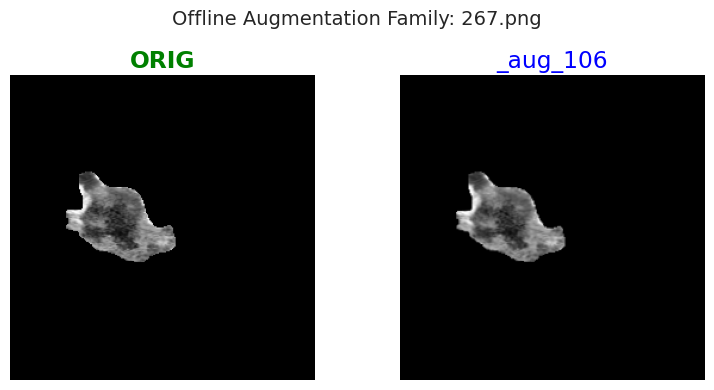

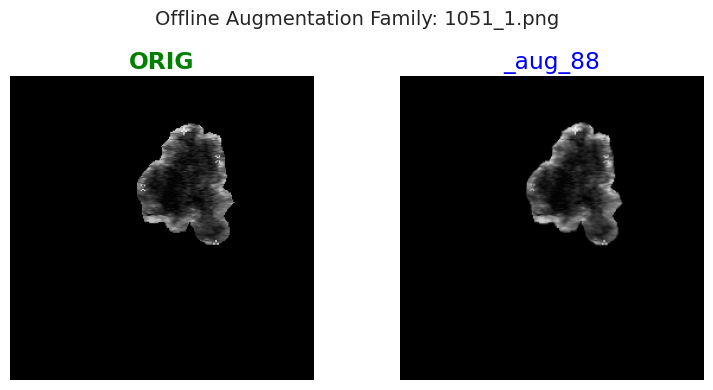

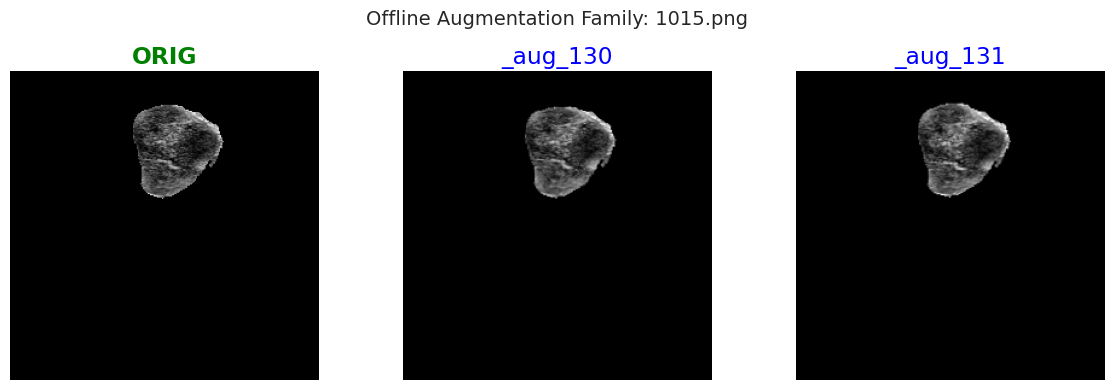


VISUALIZZAZIONE TRAINING BATCH (fold 0)

--- CONTROLLO BATCH TRAIN ---
Shape Immagini (B, C, H, W): torch.Size([16, 3, 256, 256])
Shape Label: torch.Size([16])
Range Immagine: min=0.0000, max=1.0000


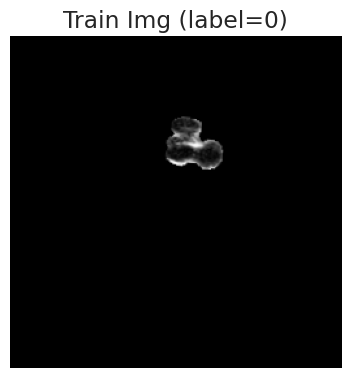


[FOLD 0] Modello caricato: {'arch': 'vgg16_3ch', 'channels_number': 3, 'classes': 2, 'model_cfg': {'dropout': 0.5, 'unfreeze_last_block': True}, 'class_weights': None}
[DEBUG] best_path = /content/drive/MyDrive/PROGETTO AI/TASK2_NEW/TASK2_MODELS_CLS/VGG16_finetuning3_equal_F1/fold_0/best.pth
[DEBUG] save_path_best passed to training = /content/drive/MyDrive/PROGETTO AI/TASK2_NEW/TASK2_MODELS_CLS/VGG16_finetuning3_equal_F1/fold_0/best.pth
[FOLD 0] Starting CLASSIFICATION training for 50 epochs



[FOLD 0] Epoch [1/50] [TRAIN]:   0%|          | 0/50 [00:00<?, ?it/s]

[FOLD 0] Epoch 1/50 | Train Loss 0.5838 Acc 0.720 F1 0.713 BalAcc 0.720 || Val Loss 0.3971 Acc 0.859 F1 0.851 BalAcc 0.881
[FOLD 0]   💾 Saved new best model (Val F1 0.8506)
────────────────────────────────────────────────────────────



[FOLD 0] Epoch [2/50] [TRAIN]:   0%|          | 0/50 [00:00<?, ?it/s]

[FOLD 0] Epoch 2/50 | Train Loss 0.3321 Acc 0.884 F1 0.884 BalAcc 0.884 || Val Loss 0.2751 Acc 0.902 F1 0.893 BalAcc 0.910
[FOLD 0]   💾 Saved new best model (Val F1 0.8931)
────────────────────────────────────────────────────────────



...

[FOLD 0] Epoch [33/50] [TRAIN]:   0%|          | 0/50 [00:00<?, ?it/s]

[FOLD 0] Epoch 33/50 | Train Loss 0.0077 Acc 0.999 F1 0.999 BalAcc 0.999 || Val Loss 0.4741 Acc 0.914 F1 0.902 BalAcc 0.898
[FOLD 0]   No improvement for 19/20 (best Val F1=0.9243)
────────────────────────────────────────────────────────────



[FOLD 0] Epoch [34/50] [TRAIN]:   0%|          | 0/50 [00:00<?, ?it/s]

[FOLD 0] Epoch 34/50 | Train Loss 0.0067 Acc 0.999 F1 0.999 BalAcc 0.999 || Val Loss 0.4739 Acc 0.917 F1 0.906 BalAcc 0.903
[FOLD 0]   No improvement for 20/20 (best Val F1=0.9243)
────────────────────────────────────────────────────────────

[FOLD 0] 🛑 Early stopping triggered after 34 epochs!
[FOLD 0] Best Val F1: 0.9243 (epoch=14) | Val Loss @ Best F1: 0.2712 | Val Acc @ Best F1: 0.9327


[EVAL]:   0%|          | 0/21 [00:00<?, ?it/s]

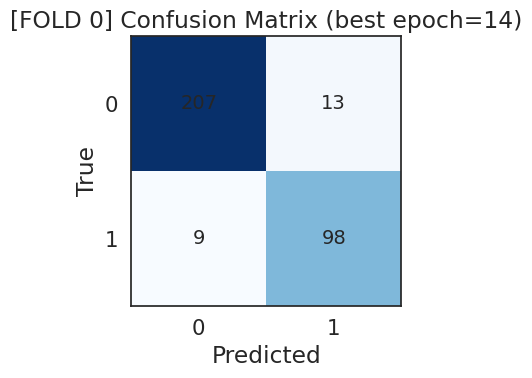


[PLOT] Training curves — Fold 0


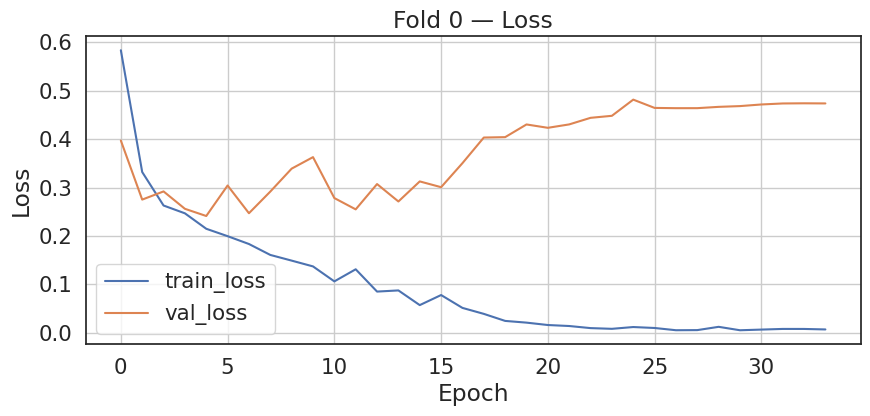

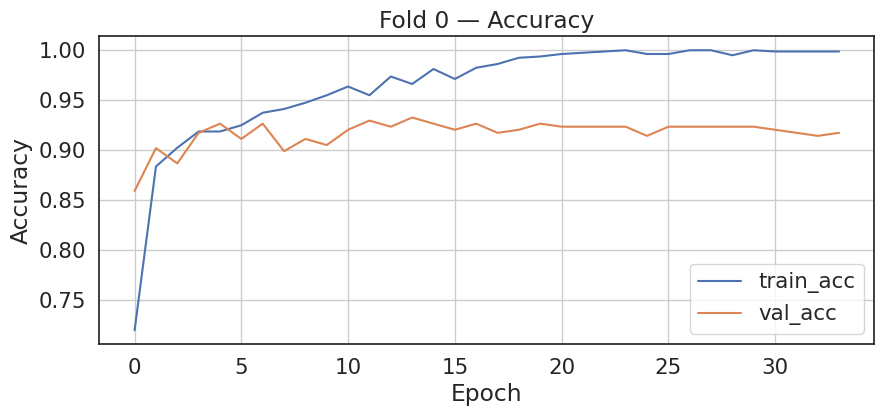


----------------------------------------------------------------------
FOLD 0 DONE
  Acc      : 0.9327
  F1 macro : 0.9243
  Bal Acc  : 0.9284
  best ckpt: /content/drive/MyDrive/PROGETTO AI/TASK2_NEW/TASK2_MODELS_CLS/VGG16_finetuning3_equal_F1/fold_0/best.pth
  best Val F1 (train-time): 0.9243119266055047
----------------------------------------------------------------------
BILANCIAMENTO DATASET OFFLINE — CLASSIFICATION
Distribuzione iniziale: {np.int64(0): np.int64(422), np.int64(1): np.int64(223)}
Target per classe: 422
> Classe 0: già bilanciata.

> Classe 1: generazione di 199 copie sintetiche...
Dataset finale bilanciato: 844 campioni
BATCH SHAPE: torch.Size([16, 3, 256, 256])

[FOLD 1] Modello caricato: {'arch': 'vgg16_3ch', 'channels_number': 3, 'classes': 2, 'model_cfg': {'dropout': 0.5, 'unfreeze_last_block': True}, 'class_weights': None}
[DEBUG] best_path = /content/drive/MyDrive/PROGETTO AI/TASK2_NEW/TASK2_MODELS_CLS/VGG16_finetuning3_equal_F1/fold_1/best.pth
[DEBUG] save

[FOLD 1] Epoch [1/50] [TRAIN]:   0%|          | 0/53 [00:00<?, ?it/s]

[FOLD 1] Epoch 1/50 | Train Loss 0.6015 Acc 0.668 F1 0.641 BalAcc 0.668 || Val Loss 0.3858 Acc 0.871 F1 0.861 BalAcc 0.868
[FOLD 1]   💾 Saved new best model (Val F1 0.8606)
────────────────────────────────────────────────────────────



[FOLD 1] Epoch [2/50] [TRAIN]:   0%|          | 0/53 [00:00<?, ?it/s]

[FOLD 1] Epoch 2/50 | Train Loss 0.3180 Acc 0.885 F1 0.885 BalAcc 0.885 || Val Loss 0.2889 Acc 0.891 F1 0.882 BalAcc 0.888
[FOLD 1]   💾 Saved new best model (Val F1 0.8815)
────────────────────────────────────────────────────────────



...

[FOLD 1] Epoch [31/50] [TRAIN]:   0%|          | 0/53 [00:00<?, ?it/s]

[FOLD 1] Epoch 31/50 | Train Loss 0.0224 Acc 0.994 F1 0.994 BalAcc 0.994 || Val Loss 0.4455 Acc 0.891 F1 0.882 BalAcc 0.888
[FOLD 1]   No improvement for 19/20 (best Val F1=0.9178)
────────────────────────────────────────────────────────────



[FOLD 1] Epoch [32/50] [TRAIN]:   0%|          | 0/53 [00:00<?, ?it/s]

[FOLD 1] Epoch 32/50 | Train Loss 0.0238 Acc 0.995 F1 0.995 BalAcc 0.995 || Val Loss 0.4455 Acc 0.894 F1 0.885 BalAcc 0.890
[FOLD 1]   No improvement for 20/20 (best Val F1=0.9178)
────────────────────────────────────────────────────────────

[FOLD 1] 🛑 Early stopping triggered after 32 epochs!
[FOLD 1] Best Val F1: 0.9178 (epoch=12) | Val Loss @ Best F1: 0.3412 | Val Acc @ Best F1: 0.9241


[EVAL]:   0%|          | 0/19 [00:00<?, ?it/s]

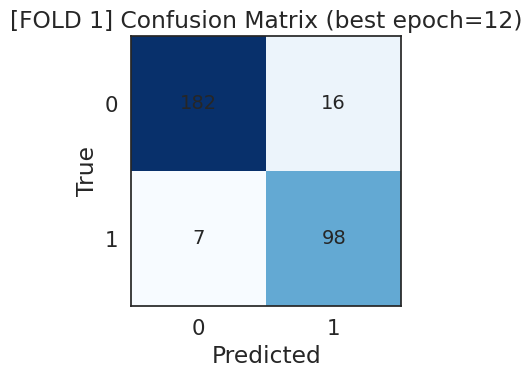


[PLOT] Training curves — Fold 1


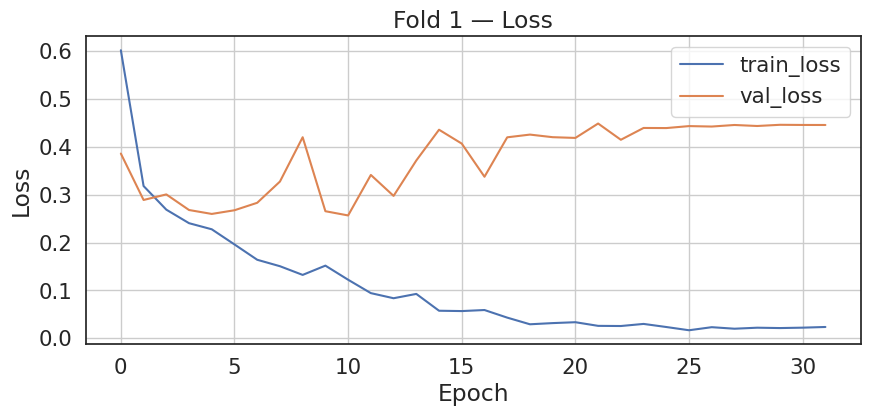

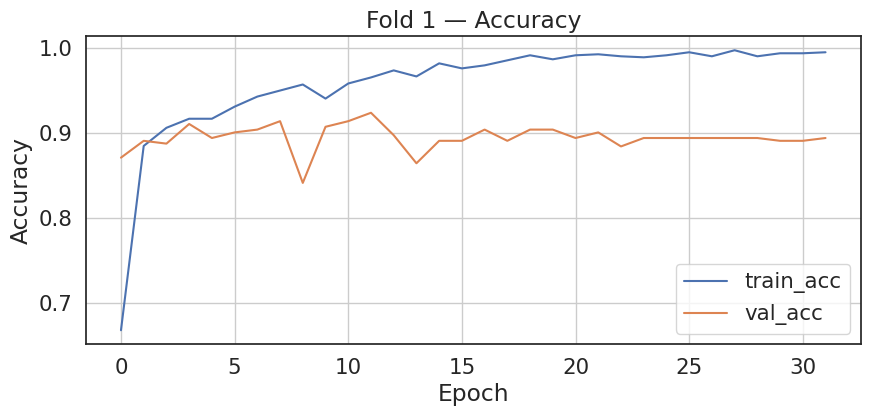


----------------------------------------------------------------------
FOLD 1 DONE
  Acc      : 0.9241
  F1 macro : 0.9178
  Bal Acc  : 0.9263
  best ckpt: /content/drive/MyDrive/PROGETTO AI/TASK2_NEW/TASK2_MODELS_CLS/VGG16_finetuning3_equal_F1/fold_1/best.pth
  best Val F1 (train-time): 0.917772822200984
----------------------------------------------------------------------
BILANCIAMENTO DATASET OFFLINE — CLASSIFICATION
Distribuzione iniziale: {np.int64(0): np.int64(418), np.int64(1): np.int64(212)}
Target per classe: 418
> Classe 0: già bilanciata.

> Classe 1: generazione di 206 copie sintetiche...
Dataset finale bilanciato: 836 campioni
BATCH SHAPE: torch.Size([16, 3, 256, 256])

[FOLD 2] Modello caricato: {'arch': 'vgg16_3ch', 'channels_number': 3, 'classes': 2, 'model_cfg': {'dropout': 0.5, 'unfreeze_last_block': True}, 'class_weights': None}
[DEBUG] best_path = /content/drive/MyDrive/PROGETTO AI/TASK2_NEW/TASK2_MODELS_CLS/VGG16_finetuning3_equal_F1/fold_2/best.pth
[DEBUG] save_

[FOLD 2] Epoch [1/50] [TRAIN]:   0%|          | 0/53 [00:00<?, ?it/s]

[FOLD 2] Epoch 1/50 | Train Loss 0.5444 Acc 0.787 F1 0.783 BalAcc 0.787 || Val Loss 0.3515 Acc 0.881 F1 0.870 BalAcc 0.867
[FOLD 2]   💾 Saved new best model (Val F1 0.8701)
────────────────────────────────────────────────────────────



[FOLD 2] Epoch [2/50] [TRAIN]:   0%|          | 0/53 [00:00<?, ?it/s]

[FOLD 2] Epoch 2/50 | Train Loss 0.2815 Acc 0.904 F1 0.904 BalAcc 0.904 || Val Loss 0.3510 Acc 0.846 F1 0.826 BalAcc 0.814
[FOLD 2]   No improvement for 1/20 (best Val F1=0.8701)
────────────────────────────────────────────────────────────



...

[FOLD 2] Epoch [20/50] [TRAIN]:   0%|          | 0/53 [00:00<?, ?it/s]

[FOLD 2] Epoch 20/50 | Train Loss 0.1159 Acc 0.968 F1 0.968 BalAcc 0.968 || Val Loss 0.3467 Acc 0.871 F1 0.858 BalAcc 0.851
[FOLD 2]   No improvement for 19/20 (best Val F1=0.8701)
────────────────────────────────────────────────────────────



[FOLD 2] Epoch [21/50] [TRAIN]:   0%|          | 0/53 [00:00<?, ?it/s]

[FOLD 2] Epoch 21/50 | Train Loss 0.1062 Acc 0.970 F1 0.970 BalAcc 0.970 || Val Loss 0.3467 Acc 0.871 F1 0.858 BalAcc 0.851
[FOLD 2]   No improvement for 20/20 (best Val F1=0.8701)
────────────────────────────────────────────────────────────

[FOLD 2] 🛑 Early stopping triggered after 21 epochs!
[FOLD 2] Best Val F1: 0.8701 (epoch=1) | Val Loss @ Best F1: 0.3515 | Val Acc @ Best F1: 0.8805


[EVAL]:   0%|          | 0/20 [00:00<?, ?it/s]

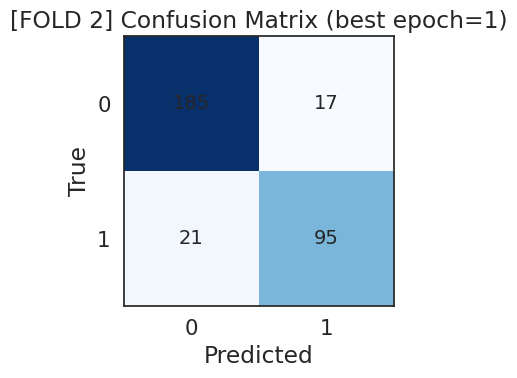


[PLOT] Training curves — Fold 2


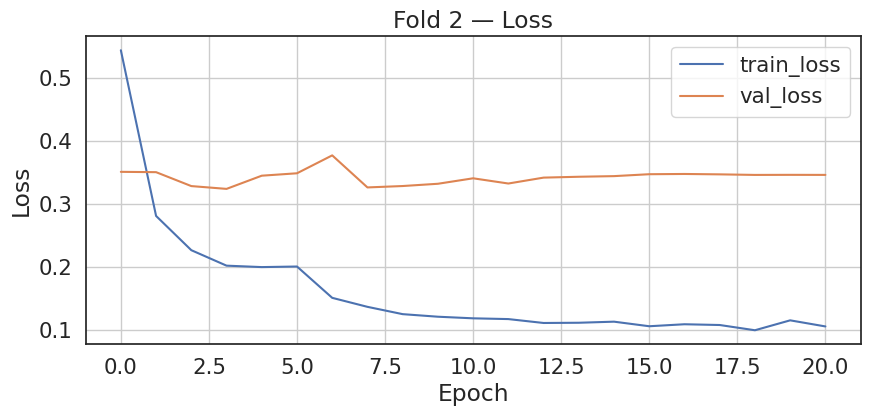

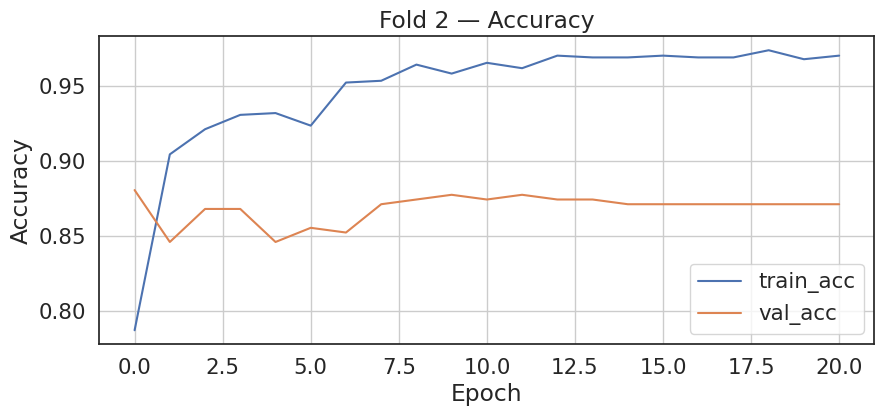


----------------------------------------------------------------------
FOLD 2 DONE
  Acc      : 0.8805
  F1 macro : 0.8701
  Bal Acc  : 0.8674
  best ckpt: /content/drive/MyDrive/PROGETTO AI/TASK2_NEW/TASK2_MODELS_CLS/VGG16_finetuning3_equal_F1/fold_2/best.pth
  best Val F1 (train-time): 0.8700980392156863
----------------------------------------------------------------------

K-FOLD SUMMARY (CLASSIFICATION) — BEST CKPT BY VAL_F1
Accuracy          : 0.9124 ± 0.0280
F1 macro          : 0.9041 ± 0.0296
Balanced Accuracy : 0.9074 ± 0.0346
Saved summary to  : /content/drive/MyDrive/PROGETTO AI/TASK2_NEW/TASK2_MODELS_CLS/VGG16_finetuning3_equal_F1/summary.json

K-FOLD RESULTS (per fold)


,fold,accuracy,f1_macro,balanced_accuracy,best_epoch,best_ckpt,best_val_f1_train,val_loss_at_best_f1
0,0,0.932722,0.924312,0.928398,14,/content/drive/MyDrive/PROGETTO AI/TASK2_NEW/T...,0.924312,0.271195
1,1,0.924092,0.917773,0.926263,12,/content/drive/MyDrive/PROGETTO AI/TASK2_NEW/T...,0.917773,0.341177
2,2,0.880503,0.870098,0.867404,1,/content/drive/MyDrive/PROGETTO AI/TASK2_NEW/T...,0.870098,0.351518


In [ ]:
# @title K-FOLD — CLASSIFICATION (VGG16) — EARLY STOPPING SU F1

N_SPLITS = 3
fold_results = []

MODELS_DIR = "/content/drive/MyDrive/PROGETTO AI/TASK2_NEW/TASK2_MODELS_CLS"
run_name   = "VGG16_finetuning3_equal_F1"
out_dir    = "/content/drive/MyDrive/PROGETTO AI/TASK2_NEW/TASK2_metadata/folds_stratified_BM"

model_cfg = {
  "arch": "vgg16_3ch",
  "channels_number": 3,
  "classes": 2,
  "model_cfg": {
      "dropout": 0.5,
      "unfreeze_last_block": True
  },
  "class_weights": None
}

run_dir = os.path.join(MODELS_DIR, run_name)
os.makedirs(run_dir, exist_ok=True)

BATCH_SIZE = 16
NUM_WORKERS = 2

N_EPOCHS = 50
LR = 5e-5
WEIGHT_DECAY = 1e-3
PATIENCE = 20
MIN_LR = 1e-9
SEED = 42

fold_histories = []

for fold_id in range(N_SPLITS):

    fold_csv = f"{out_dir}/fold_{fold_id}.csv"

    # 1) Build loaders
    if fold_id == 0:
        train_loader, val_loader, X_bal, fn_bal = build_fold_loaders_cls(
            fold_csv_path=fold_csv,
            X_all=X_cls,
            y_all=y_cls,
            filenames_all=fnames_orig,
            channels_number=model_cfg["channels_number"],
            batch_size=BATCH_SIZE,
            num_workers=NUM_WORKERS,
            seed=SEED + fold_id,
            return_offline_data=True
        )
        print("\nVISUALIZZAZIONE OFFLINE AUGMENTATION (fold 0)")
        visualize_augmentation_results_cls(X_bal, fn_bal)

        print("\nVISUALIZZAZIONE TRAINING BATCH (fold 0)")
        visualize_one_train_batch_cls(train_loader, n_show=1)

    else:
        train_loader, val_loader = build_fold_loaders_cls(
            fold_csv_path=fold_csv,
            X_all=X_cls,
            y_all=y_cls,
            filenames_all=fnames_orig,
            channels_number=model_cfg["channels_number"],
            batch_size=BATCH_SIZE,
            num_workers=NUM_WORKERS,
            seed=SEED + fold_id,
            return_offline_data=False
        )
        xb, yb, _ = next(iter(train_loader))
        print("BATCH SHAPE:", xb.shape)

    # 2) Run fold (F1 early stopping)
    res = run_one_fold_cls_f1(
        fold_id=fold_id,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        MODELS_DIR=MODELS_DIR,
        run_name=run_name,
        model_cfg=model_cfg,
        n_epochs=N_EPOCHS,
        patience=PATIENCE,
        lr=LR,
        min_lr=MIN_LR,
        weight_decay=WEIGHT_DECAY,
        fold_csv_path=fold_csv,
        seed=SEED + fold_id,
        class_names=None
    )

    # plot training curves
    paths = get_fold_paths_simple(MODELS_DIR, run_name, fold_id)
    history_csv = paths["history_csv"]
    if os.path.exists(history_csv):
        history_df = pd.read_csv(history_csv)
        print(f"\n[PLOT] Training curves — Fold {fold_id}")
        plot_history_one_fold(history_df, fold_id)

    fold_results.append(res)

    print("\n" + "-"*70)
    print(f"FOLD {fold_id} DONE")
    print(f"  Acc      : {res['accuracy']:.4f}")
    print(f"  F1 macro : {res['f1_macro']:.4f}")
    print(f"  Bal Acc  : {res['balanced_accuracy']:.4f}")
    print(f"  best ckpt: {res['best_path']}")
    if "best_val_f1_during_training" in res:
        print(f"  best Val F1 (train-time): {res['best_val_f1_during_training']}")
    print("-"*70)

    if os.path.exists(history_csv):
        h = pd.read_csv(history_csv)
        fold_histories.append({"fold": fold_id, "history": h})

    del train_loader, val_loader
    gc.collect()

# ==========================
# SUMMARY mean ± std
# ==========================
acc_vals     = np.array([r["accuracy"] for r in fold_results], dtype=float)
f1_vals      = np.array([r["f1_macro"] for r in fold_results], dtype=float)
balacc_vals  = np.array([r["balanced_accuracy"] for r in fold_results], dtype=float)

summary = {
    "run_name": run_name,
    "model_cfg": model_cfg,
    "n_splits": N_SPLITS,
    "accuracy_mean": float(acc_vals.mean()),
    "accuracy_std":  float(acc_vals.std(ddof=1)) if len(acc_vals) > 1 else 0.0,
    "f1_macro_mean": float(f1_vals.mean()),
    "f1_macro_std":  float(f1_vals.std(ddof=1)) if len(f1_vals) > 1 else 0.0,
    "balanced_accuracy_mean": float(balacc_vals.mean()),
    "balanced_accuracy_std":  float(balacc_vals.std(ddof=1)) if len(balacc_vals) > 1 else 0.0,
    "folds": fold_results
}

summary_path = os.path.join(run_dir, "summary.json")
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print("\n" + "="*90)
print("K-FOLD SUMMARY (CLASSIFICATION) — BEST CKPT BY VAL_F1")
print("="*90)
print(f"Accuracy          : {acc_vals.mean():.4f} ± {acc_vals.std(ddof=1) if len(acc_vals)>1 else 0.0:.4f}")
print(f"F1 macro          : {f1_vals.mean():.4f} ± {f1_vals.std(ddof=1) if len(f1_vals)>1 else 0.0:.4f}")
print(f"Balanced Accuracy : {balacc_vals.mean():.4f} ± {balacc_vals.std(ddof=1) if len(balacc_vals)>1 else 0.0:.4f}")
print(f"Saved summary to  : {summary_path}")
print("="*90)

from IPython.display import display

df_folds = pd.DataFrame([{
    "fold": int(r["fold"]),
    "accuracy": float(r["accuracy"]),
    "f1_macro": float(r["f1_macro"]),
    "balanced_accuracy": float(r["balanced_accuracy"]),
    "best_epoch": r.get("best_epoch", np.nan),
    "best_ckpt": r.get("best_path", ""),
    "best_val_f1_train": r.get("best_val_f1_during_training", np.nan),
    "val_loss_at_best_f1": r.get("val_loss_at_best_f1", np.nan),
} for r in fold_results]).sort_values("fold").reset_index(drop=True)

print("\n" + "="*90)
print("K-FOLD RESULTS (per fold)")
print("="*90)
display(df_folds)


## VGG16 - finetuning3 - pesi uguali alle classi - early stopping su loss

BILANCIAMENTO DATASET OFFLINE — CLASSIFICATION
Distribuzione iniziale: {np.int64(0): np.int64(400), np.int64(1): np.int64(221)}
Target per classe: 400
> Classe 0: già bilanciata.

> Classe 1: generazione di 179 copie sintetiche...
Dataset finale bilanciato: 800 campioni

VISUALIZZAZIONE OFFLINE AUGMENTATION (fold 0)
[INFO] Visualizzo 3 famiglie (max 2 copie per famiglia).


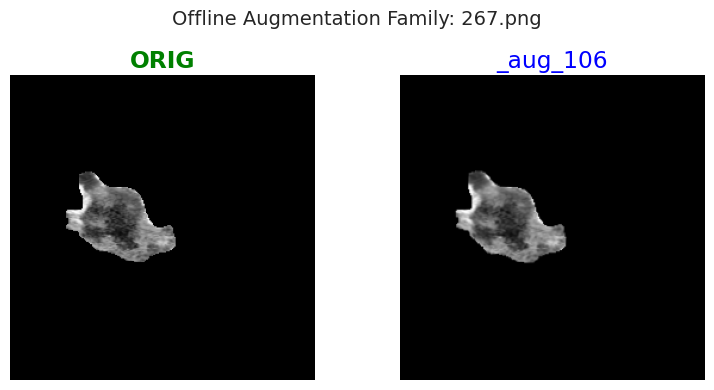

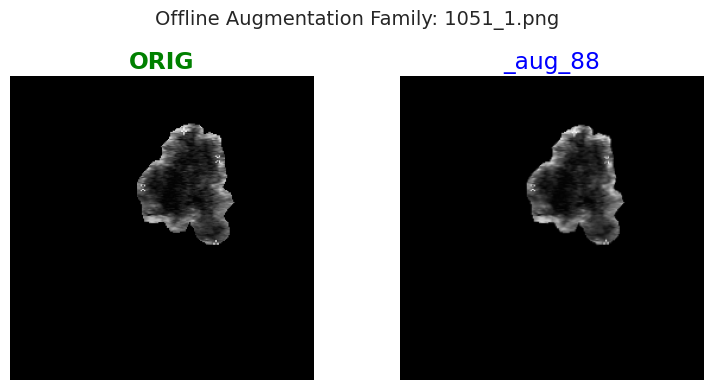

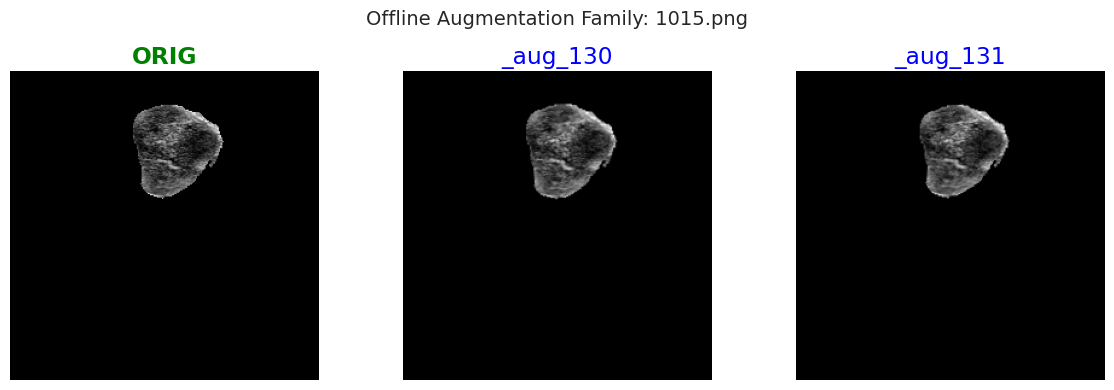


VISUALIZZAZIONE TRAINING BATCH (fold 0)

--- CONTROLLO BATCH TRAIN ---
Shape Immagini (B, C, H, W): torch.Size([16, 3, 256, 256])
Shape Label: torch.Size([16])
Range Immagine: min=0.0000, max=1.0000


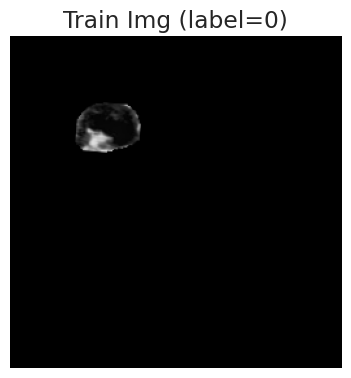


[FOLD 0] Modello caricato: {'arch': 'vgg16_3ch', 'channels_number': 3, 'classes': 2, 'model_cfg': {'dropout': 0.5, 'unfreeze_last_block': True}, 'class_weights': None}
[DEBUG] best_path = /content/drive/MyDrive/PROGETTO AI/TASK2_NEW/TASK2_MODELS_CLS/VGG16_finetuning3_equal/fold_0/best.pth
[DEBUG] save_path_best passed to training = /content/drive/MyDrive/PROGETTO AI/TASK2_NEW/TASK2_MODELS_CLS/VGG16_finetuning3_equal/fold_0/best.pth
[FOLD 0] Starting CLASSIFICATION training for 50 epochs



[FOLD 0] Epoch [1/50] [TRAIN]:   0%|          | 0/50 [00:00<?, ?it/s]

[FOLD 0] Epoch 1/50 | Train Loss 0.5849 Acc 0.715 F1 0.707 BalAcc 0.715 || Val Loss 0.3902 Acc 0.869 F1 0.860 BalAcc 0.888
[FOLD 0]   💾 Saved new best model (Val Loss 0.3902)
────────────────────────────────────────────────────────────



[FOLD 0] Epoch [2/50] [TRAIN]:   0%|          | 0/50 [00:00<?, ?it/s]

[FOLD 0] Epoch 2/50 | Train Loss 0.3305 Acc 0.882 F1 0.882 BalAcc 0.883 || Val Loss 0.2832 Acc 0.893 F1 0.884 BalAcc 0.904
[FOLD 0]   💾 Saved new best model (Val Loss 0.2832)
────────────────────────────────────────────────────────────



...

[FOLD 0] Epoch [24/50] [TRAIN]:   0%|          | 0/50 [00:00<?, ?it/s]

[FOLD 0] Epoch 24/50 | Train Loss 0.0699 Acc 0.980 F1 0.980 BalAcc 0.980 || Val Loss 0.3050 Acc 0.927 F1 0.916 BalAcc 0.914
[FOLD 0]   No improvement for 19/20
────────────────────────────────────────────────────────────



[FOLD 0] Epoch [25/50] [TRAIN]:   0%|          | 0/50 [00:00<?, ?it/s]

[FOLD 0] Epoch 25/50 | Train Loss 0.0693 Acc 0.978 F1 0.977 BalAcc 0.978 || Val Loss 0.3051 Acc 0.927 F1 0.916 BalAcc 0.914
[FOLD 0]   No improvement for 20/20
────────────────────────────────────────────────────────────

[FOLD 0] 🛑 Early stopping triggered after 25 epochs!
[FOLD 0] Best Val Loss: 0.2439 | Best Val Acc: 0.9235


[EVAL]:   0%|          | 0/21 [00:00<?, ?it/s]

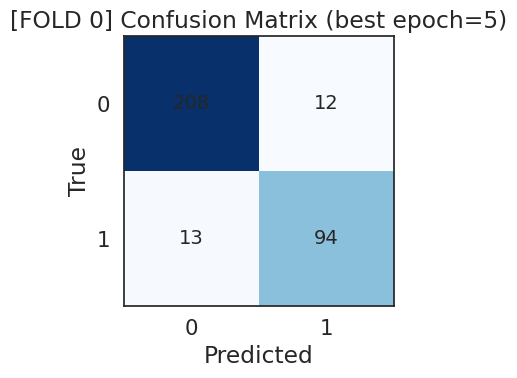


[PLOT] Training curves — Fold 0


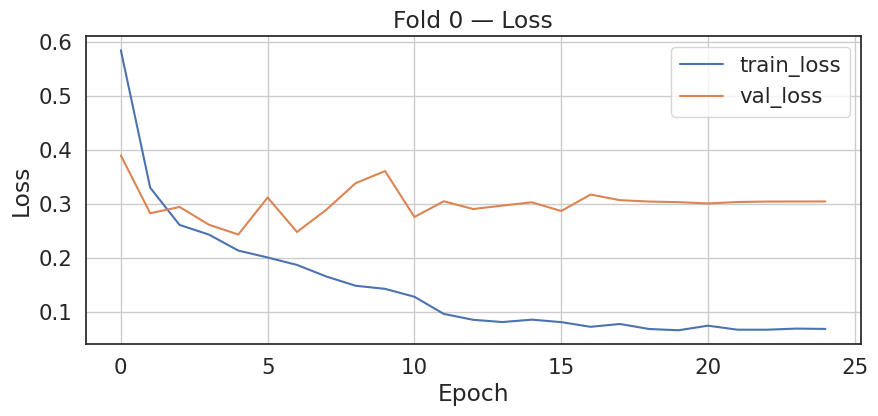

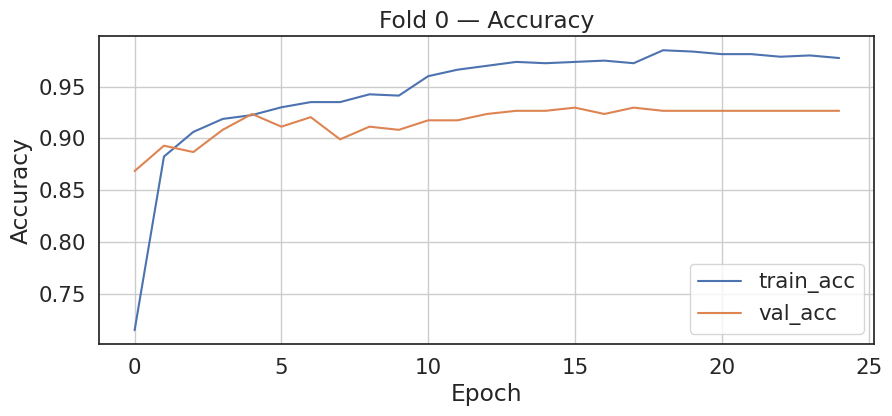


----------------------------------------------------------------------
FOLD 0 DONE
  Acc      : 0.9235
  F1 macro : 0.9130
  Bal Acc  : 0.9120
  best ckpt: /content/drive/MyDrive/PROGETTO AI/TASK2_NEW/TASK2_MODELS_CLS/VGG16_finetuning3_equal/fold_0/best.pth
----------------------------------------------------------------------
BILANCIAMENTO DATASET OFFLINE — CLASSIFICATION
Distribuzione iniziale: {np.int64(0): np.int64(422), np.int64(1): np.int64(223)}
Target per classe: 422
> Classe 0: già bilanciata.

> Classe 1: generazione di 199 copie sintetiche...
Dataset finale bilanciato: 844 campioni
BATCH SHAPE: torch.Size([16, 3, 256, 256])

[FOLD 1] Modello caricato: {'arch': 'vgg16_3ch', 'channels_number': 3, 'classes': 2, 'model_cfg': {'dropout': 0.5, 'unfreeze_last_block': True}, 'class_weights': None}
[DEBUG] best_path = /content/drive/MyDrive/PROGETTO AI/TASK2_NEW/TASK2_MODELS_CLS/VGG16_finetuning3_equal/fold_1/best.pth
[DEBUG] save_path_best passed to training = /content/drive/MyDriv

[FOLD 1] Epoch [1/50] [TRAIN]:   0%|          | 0/53 [00:00<?, ?it/s]

[FOLD 1] Epoch 1/50 | Train Loss 0.5979 Acc 0.673 F1 0.648 BalAcc 0.673 || Val Loss 0.3761 Acc 0.871 F1 0.861 BalAcc 0.868
[FOLD 1]   💾 Saved new best model (Val Loss 0.3761)
────────────────────────────────────────────────────────────



[FOLD 1] Epoch [2/50] [TRAIN]:   0%|          | 0/53 [00:00<?, ?it/s]

[FOLD 1] Epoch 2/50 | Train Loss 0.3200 Acc 0.891 F1 0.891 BalAcc 0.891 || Val Loss 0.2826 Acc 0.888 F1 0.878 BalAcc 0.883
[FOLD 1]   💾 Saved new best model (Val Loss 0.2826)
────────────────────────────────────────────────────────────



...

[FOLD 1] Epoch [30/50] [TRAIN]:   0%|          | 0/53 [00:00<?, ?it/s]

[FOLD 1] Epoch 30/50 | Train Loss 0.0270 Acc 0.992 F1 0.992 BalAcc 0.992 || Val Loss 0.4142 Acc 0.901 F1 0.893 BalAcc 0.900
[FOLD 1]   No improvement for 19/20
────────────────────────────────────────────────────────────



[FOLD 1] Epoch [31/50] [TRAIN]:   0%|          | 0/53 [00:00<?, ?it/s]

[FOLD 1] Epoch 31/50 | Train Loss 0.0284 Acc 0.993 F1 0.993 BalAcc 0.993 || Val Loss 0.4143 Acc 0.901 F1 0.893 BalAcc 0.900
[FOLD 1]   No improvement for 20/20
────────────────────────────────────────────────────────────

[FOLD 1] 🛑 Early stopping triggered after 31 epochs!
[FOLD 1] Best Val Loss: 0.2502 | Best Val Acc: 0.9241


[EVAL]:   0%|          | 0/19 [00:00<?, ?it/s]

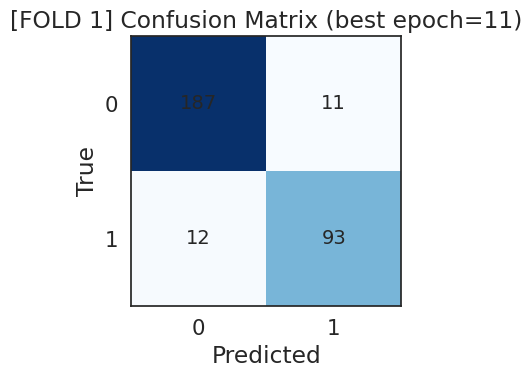


[PLOT] Training curves — Fold 1


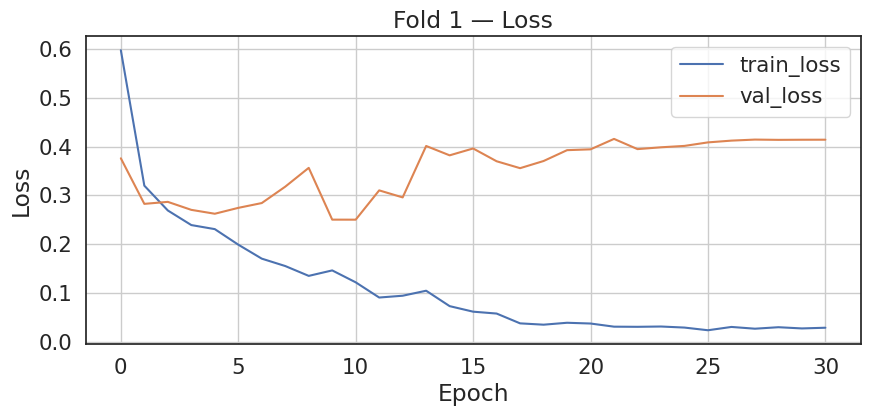

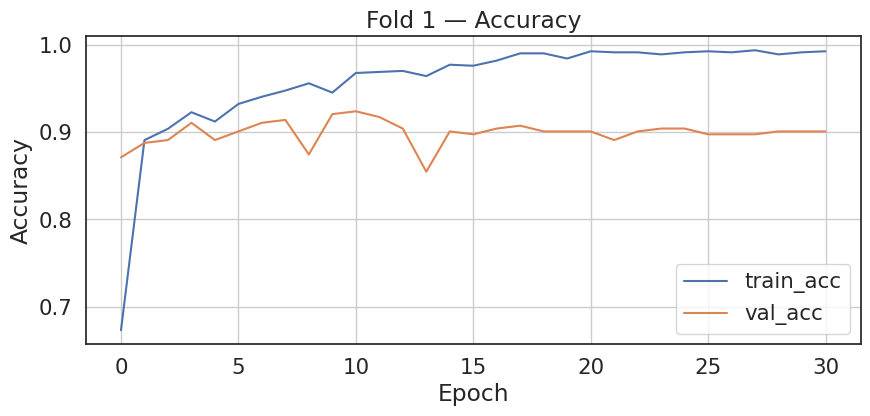


----------------------------------------------------------------------
FOLD 1 DONE
  Acc      : 0.9241
  F1 macro : 0.9160
  Bal Acc  : 0.9151
  best ckpt: /content/drive/MyDrive/PROGETTO AI/TASK2_NEW/TASK2_MODELS_CLS/VGG16_finetuning3_equal/fold_1/best.pth
----------------------------------------------------------------------
BILANCIAMENTO DATASET OFFLINE — CLASSIFICATION
Distribuzione iniziale: {np.int64(0): np.int64(418), np.int64(1): np.int64(212)}
Target per classe: 418
> Classe 0: già bilanciata.

> Classe 1: generazione di 206 copie sintetiche...
Dataset finale bilanciato: 836 campioni
BATCH SHAPE: torch.Size([16, 3, 256, 256])

[FOLD 2] Modello caricato: {'arch': 'vgg16_3ch', 'channels_number': 3, 'classes': 2, 'model_cfg': {'dropout': 0.5, 'unfreeze_last_block': True}, 'class_weights': None}
[DEBUG] best_path = /content/drive/MyDrive/PROGETTO AI/TASK2_NEW/TASK2_MODELS_CLS/VGG16_finetuning3_equal/fold_2/best.pth
[DEBUG] save_path_best passed to training = /content/drive/MyDriv

[FOLD 2] Epoch [1/50] [TRAIN]:   0%|          | 0/53 [00:00<?, ?it/s]

[FOLD 2] Epoch 1/50 | Train Loss 0.5481 Acc 0.778 F1 0.773 BalAcc 0.778 || Val Loss 0.3565 Acc 0.881 F1 0.870 BalAcc 0.867
[FOLD 2]   💾 Saved new best model (Val Loss 0.3565)
────────────────────────────────────────────────────────────



[FOLD 2] Epoch [2/50] [TRAIN]:   0%|          | 0/53 [00:00<?, ?it/s]

[FOLD 2] Epoch 2/50 | Train Loss 0.2804 Acc 0.906 F1 0.906 BalAcc 0.906 || Val Loss 0.3573 Acc 0.843 F1 0.822 BalAcc 0.810
[FOLD 2]   No improvement for 1/20
────────────────────────────────────────────────────────────



...

[FOLD 2] Epoch [22/50] [TRAIN]:   0%|          | 0/53 [00:00<?, ?it/s]

[FOLD 2] Epoch 22/50 | Train Loss 0.0733 Acc 0.976 F1 0.976 BalAcc 0.976 || Val Loss 0.3876 Acc 0.877 F1 0.864 BalAcc 0.856
[FOLD 2]   No improvement for 19/20
────────────────────────────────────────────────────────────



[FOLD 2] Epoch [23/50] [TRAIN]:   0%|          | 0/53 [00:00<?, ?it/s]

[FOLD 2] Epoch 23/50 | Train Loss 0.0745 Acc 0.978 F1 0.978 BalAcc 0.978 || Val Loss 0.3880 Acc 0.877 F1 0.864 BalAcc 0.856
[FOLD 2]   No improvement for 20/20
────────────────────────────────────────────────────────────

[FOLD 2] 🛑 Early stopping triggered after 23 epochs!
[FOLD 2] Best Val Loss: 0.3301 | Best Val Acc: 0.8648


[EVAL]:   0%|          | 0/20 [00:00<?, ?it/s]

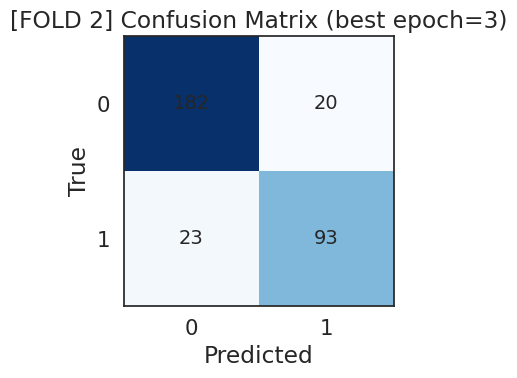


[PLOT] Training curves — Fold 2


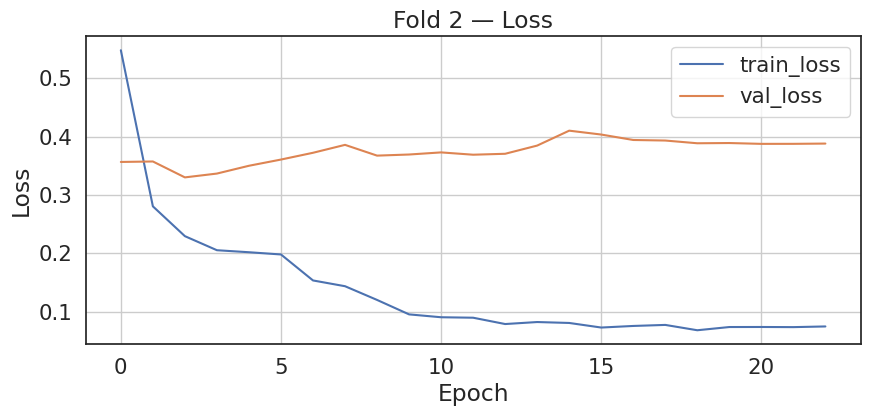

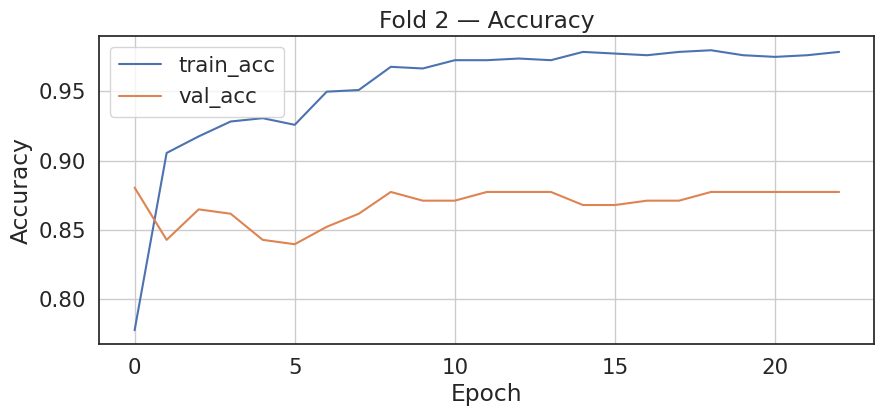


----------------------------------------------------------------------
FOLD 2 DONE
  Acc      : 0.8648
  F1 macro : 0.8533
  Bal Acc  : 0.8514
  best ckpt: /content/drive/MyDrive/PROGETTO AI/TASK2_NEW/TASK2_MODELS_CLS/VGG16_finetuning3_equal/fold_2/best.pth
----------------------------------------------------------------------

K-FOLD SUMMARY (CLASSIFICATION)
Accuracy          : 0.9041 ± 0.0341
F1 macro          : 0.8941 ± 0.0354
Balanced Accuracy : 0.8928 ± 0.0359
Saved summary to  : /content/drive/MyDrive/PROGETTO AI/TASK2_NEW/TASK2_MODELS_CLS/VGG16_finetuning3_equal/summary.json

K-FOLD RESULTS (per fold)


,fold,accuracy,f1_macro,balanced_accuracy,best_epoch,best_ckpt
0,0,0.923547,0.912970,0.911980,5,/content/drive/MyDrive/PROGETTO AI/TASK2_NEW/T...
1,1,0.924092,0.916009,0.915079,11,/content/drive/MyDrive/PROGETTO AI/TASK2_NEW/T...
2,2,0.864780,0.853288,0.851357,3,/content/drive/MyDrive/PROGETTO AI/TASK2_NEW/T...



K-FOLD SUMMARY (mean ± std)


,accuracy,f1_macro,balanced_accuracy,best_epoch
0,0.9041 ± 0.0341,0.8941 ± 0.0354,0.8928 ± 0.0359,6.3 ± 4.2


In [ ]:
# @title K-FOLD — CLASSIFICATION (VGG16)

N_SPLITS = 3
fold_results = []

MODELS_DIR = "/content/drive/MyDrive/PROGETTO AI/TASK2_NEW/TASK2_MODELS_CLS"
run_name   = "VGG16_finetuning3_equal"
out_dir    = "/content/drive/MyDrive/PROGETTO AI/TASK2_NEW/TASK2_metadata/folds_stratified_BM"

model_cfg = {
  "arch": "vgg16_3ch",
  "channels_number": 3,
  "classes": 2,
  "model_cfg": {
      "dropout": 0.5,         5
      "unfreeze_last_block": True
  },
  "class_weights": None
}


run_dir = os.path.join(MODELS_DIR, run_name)
os.makedirs(run_dir, exist_ok=True)

BATCH_SIZE = 16
NUM_WORKERS = 2


N_EPOCHS = 50
LR = 5e-5
WEIGHT_DECAY = 1e-3
PATIENCE = 20

MIN_LR= 1e-9

SEED = 42


fold_histories = []

for fold_id in range(N_SPLITS):

    fold_csv = f"{out_dir}/fold_{fold_id}.csv"

    # 1) Build loaders
    if fold_id == 0:
        train_loader, val_loader, X_bal, fn_bal = build_fold_loaders_cls(
            fold_csv_path=fold_csv,
            X_all=X_cls,
            y_all=y_cls,
            filenames_all=fnames_orig,
            channels_number=model_cfg["channels_number"],
            batch_size=BATCH_SIZE,
            num_workers=NUM_WORKERS,
            seed=SEED + fold_id,
            return_offline_data=True
        )

        print("\nVISUALIZZAZIONE OFFLINE AUGMENTATION (fold 0)")
        visualize_augmentation_results_cls(X_bal, fn_bal)

        print("\nVISUALIZZAZIONE TRAINING BATCH (fold 0)")
        visualize_one_train_batch_cls(train_loader, n_show=1)

    else:
        train_loader, val_loader = build_fold_loaders_cls(
            fold_csv_path=fold_csv,
            X_all=X_cls,
            y_all=y_cls,
            filenames_all=fnames_orig,
            channels_number=model_cfg["channels_number"],
            batch_size=BATCH_SIZE,
            num_workers=NUM_WORKERS,
            seed=SEED + fold_id,
            return_offline_data=False
        )

        xb, yb, _ = next(iter(train_loader))
        print("BATCH SHAPE:", xb.shape)


    # 2) Run fold
    res = run_one_fold_cls(
        fold_id=fold_id,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        MODELS_DIR=MODELS_DIR,
        run_name=run_name,
        model_cfg=model_cfg,
        n_epochs=N_EPOCHS,
        patience=PATIENCE,
        lr=LR,
        min_lr=MIN_LR,
        weight_decay=WEIGHT_DECAY,
        fold_csv_path=fold_csv,
        seed=SEED + fold_id,
        class_names=None
    )

    # ==========================
    # PLOT TRAINING CURVES
    # ==========================
    paths = get_fold_paths_simple(MODELS_DIR, run_name, fold_id)
    history_csv = paths["history_csv"]

    if os.path.exists(history_csv):
        history_df = pd.read_csv(history_csv)
        print(f"\n[PLOT] Training curves — Fold {fold_id}")
        plot_history_one_fold(history_df, fold_id)


    fold_results.append(res)

    print("\n" + "-"*70)
    print(f"FOLD {fold_id} DONE")
    print(f"  Acc      : {res['accuracy']:.4f}")
    print(f"  F1 macro : {res['f1_macro']:.4f}")
    print(f"  Bal Acc  : {res['balanced_accuracy']:.4f}")
    print(f"  best ckpt: {res['best_path']}")
    print("-"*70)

    paths = get_fold_paths_simple(MODELS_DIR, run_name, fold_id)
    history_csv = paths["history_csv"]
    if os.path.exists(history_csv):
        h = pd.read_csv(history_csv)
        fold_histories.append({"fold": fold_id, "history": h})

    del train_loader, val_loader
    gc.collect()



# ==========================
# SUMMARY mean ± std
# ==========================

acc_vals     = np.array([r["accuracy"] for r in fold_results], dtype=float)
f1_vals      = np.array([r["f1_macro"] for r in fold_results], dtype=float)
balacc_vals  = np.array([r["balanced_accuracy"] for r in fold_results], dtype=float)

summary = {
    "run_name": run_name,
    "model_cfg": model_cfg,
    "n_splits": N_SPLITS,
    "accuracy_mean": float(acc_vals.mean()),
    "accuracy_std":  float(acc_vals.std(ddof=1)) if len(acc_vals) > 1 else 0.0,
    "f1_macro_mean": float(f1_vals.mean()),
    "f1_macro_std":  float(f1_vals.std(ddof=1)) if len(f1_vals) > 1 else 0.0,
    "balanced_accuracy_mean": float(balacc_vals.mean()),
    "balanced_accuracy_std":  float(balacc_vals.std(ddof=1)) if len(balacc_vals) > 1 else 0.0,
    "folds": fold_results
}

summary_path = os.path.join(run_dir, "summary.json")
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print("\n" + "="*90)
print("K-FOLD SUMMARY (CLASSIFICATION)")
print("="*90)
print(f"Accuracy          : {acc_vals.mean():.4f} ± {acc_vals.std(ddof=1) if len(acc_vals)>1 else 0.0:.4f}")
print(f"F1 macro          : {f1_vals.mean():.4f} ± {f1_vals.std(ddof=1) if len(f1_vals)>1 else 0.0:.4f}")
print(f"Balanced Accuracy : {balacc_vals.mean():.4f} ± {balacc_vals.std(ddof=1) if len(balacc_vals)>1 else 0.0:.4f}")
print(f"Saved summary to  : {summary_path}")
print("="*90)


from IPython.display import display

df_folds = pd.DataFrame([{
    "fold": int(r["fold"]),
    "accuracy": float(r["accuracy"]),
    "f1_macro": float(r["f1_macro"]),
    "balanced_accuracy": float(r["balanced_accuracy"]),
    "best_epoch": r.get("best_epoch", np.nan),
    "best_ckpt": r.get("best_path", "")
} for r in fold_results]).sort_values("fold").reset_index(drop=True)

print("\n" + "="*90)
print("K-FOLD RESULTS (per fold)")
print("="*90)
display(df_folds)

df_summary = pd.DataFrame([{
    "accuracy": f"{df_folds['accuracy'].mean():.4f} ± {df_folds['accuracy'].std(ddof=1) if len(df_folds)>1 else 0.0:.4f}",
    "f1_macro": f"{df_folds['f1_macro'].mean():.4f} ± {df_folds['f1_macro'].std(ddof=1) if len(df_folds)>1 else 0.0:.4f}",
    "balanced_accuracy": f"{df_folds['balanced_accuracy'].mean():.4f} ± {df_folds['balanced_accuracy'].std(ddof=1) if len(df_folds)>1 else 0.0:.4f}",
    "best_epoch": f"{pd.to_numeric(df_folds['best_epoch'], errors='coerce').mean():.1f} ± {pd.to_numeric(df_folds['best_epoch'], errors='coerce').std(ddof=1) if len(df_folds)>1 else 0.0:.1f}",
}])

print("\n" + "="*90)
print("K-FOLD SUMMARY (mean ± std)")
print("="*90)
display(df_summary)


# Retrain best model

## Retrain - TrainVal

In [ ]:
# @title retrain

def retrain_cls_trainval(
    X_all, y_all, filenames_all,
    trainval_csv_path,
    device,
    MODELS_DIR,
    run_name,
    model_cfg,
    n_epochs,
    batch_size=16,
    num_workers=2,
    lr=5e-5,
    weight_decay=1e-3,
    seed=42,
    ignore_class=2,                 # NORMAL
    class_names=("Benign", "Malignant"),
    plot_curves=True
):
    """
    RETRAIN CLASSIFICATION FINALE (SOLO TRAINVAL) — NO HOLDOUT
    - Filtra il pool usando TrainVal.csv (filename + opzionale split=trainval)
    - Esclude ignore_class (default: 2 NORMAL)
    - Offline augmentation/balancing SOLO sui TrainVal (non-normal)
    - Train per n_epochs fissi, salva checkpoint finale
    """

    print("\n" + "="*70)
    print("RETRAIN CLS — SOLO TRAINVAL (NO HOLDOUT, NO TEST)")
    print("="*70)

    # -------------------------
    # 1) Load TrainVal.csv + set
    # -------------------------
    if not os.path.exists(trainval_csv_path):
        raise FileNotFoundError(f"TrainVal.csv non trovato: {trainval_csv_path}")

    tv_df = pd.read_csv(trainval_csv_path)
    if "filename" not in tv_df.columns:
        raise ValueError("TrainVal.csv deve contenere la colonna 'filename'.")

    if "split" in tv_df.columns:
        tv_df = tv_df[tv_df["split"].astype(str).str.lower() == "trainval"].copy()

    tv_set = set(tv_df["filename"].astype(str).values)

    # -------------------------
    # 2) Filter pool by TrainVal filenames
    # -------------------------
    fn = np.asarray(filenames_all).astype(str)
    mask_tv = np.isin(fn, list(tv_set))

    X_tv = np.asarray(X_all)[mask_tv]
    y_tv = np.asarray(y_all).astype(int)[mask_tv]
    fn_tv = fn[mask_tv]

    missing = tv_set - set(fn_tv.tolist())

    print(f"📦 Pool totale            : {len(fn)}")
    print(f"✅ TrainVal.csv (rows)     : {len(tv_df)}")
    print(f"✅ Presi dal pool (TV)     : {len(fn_tv)}")
    print(f"⚠️ TV mancanti nel pool    : {len(missing)}")
    if len(missing) > 0:
        print("   esempi missing:", list(missing)[:10])

    if len(fn_tv) == 0:
        raise RuntimeError("Dopo filtro TrainVal, nessun campione rimasto. Controlla i filename.")

    # -------------------------
    # 3) Exclude NORMAL (ignore_class)
    # -------------------------
    if ignore_class is not None:
        keep = (y_tv != int(ignore_class))
        X_tv = X_tv[keep]
        y_tv = y_tv[keep]
        fn_tv = fn_tv[keep]

    print(f"🚫 Rimossi ignore_class={ignore_class} -> rimangono: {len(fn_tv)}")

    # labels devono essere 0/1 per CE a 2 classi
    uniq = np.unique(y_tv)
    if set(uniq.tolist()) != {0, 1}:
        raise ValueError(f"Dopo filtro NORMAL mi aspetto label {{0,1}}. Trovate: {uniq}")

    # -------------------------
    # 4) Seed
    # -------------------------
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # -------------------------
    # 5) Offline balancing
    # -------------------------
    X_bal, y_bal, fn_bal = balance_dataset_offline_cls(X_tv, y_tv, fn_tv)

    # -------------------------
    # 6) DataLoader (train only)
    # -------------------------
    channels_number = int(model_cfg.get("channels_number", 1))

    train_ds = BreastUSClassificationDataset(
        X_bal, y_bal,
        filenames=fn_bal,
        transform=train_transform,
        channels_number=channels_number
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True
    )

    # -------------------------
    # 7) Paths
    # -------------------------
    run_dir = os.path.join(MODELS_DIR, run_name, "retrain_trainval")
    os.makedirs(run_dir, exist_ok=True)

    last_path    = os.path.join(run_dir, "last.pth")
    history_csv  = os.path.join(run_dir, "history.csv")
    metrics_json = os.path.join(run_dir, "metrics.json")

    # -------------------------
    # 8) Model + loss + opt + sched
    # -------------------------
    model = make_model(
        arch=model_cfg["arch"],
        channels_number=channels_number,
        classes=int(model_cfg.get("classes", 2)),
        device=device,
        model_cfg=model_cfg.get("model_cfg", None)
    )
    print(f"🧠 Model cfg: {model_cfg}")

    cw = model_cfg.get("class_weights", None)
    if cw is not None:
        cw = torch.tensor(cw, dtype=torch.float32).to(device)
        criterion = nn.CrossEntropyLoss(weight=cw)
    else:
        criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=weight_decay
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.1, patience=5,
        min_lr=float(model_cfg.get("min_lr", 1e-9))
    )

    # -------------------------
    # 9) Train loop (train-only)
    # -------------------------
    history = {"loss": [], "acc": [], "f1": []}

    for epoch in range(int(n_epochs)):
        model.train()
        epoch_loss = 0.0
        y_true_all = []
        y_pred_all = []

        for xb, yb, _ in train_loader:
            xb = xb.to(device)
            yb = yb.to(device).long()

            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            y_true_all.append(yb.detach().cpu().numpy())
            y_pred_all.append(preds.detach().cpu().numpy())

        epoch_loss /= max(1, len(train_loader))
        y_true = np.concatenate(y_true_all) if y_true_all else np.array([])
        y_pred = np.concatenate(y_pred_all) if y_pred_all else np.array([])

        # metriche train (semplici)
        acc = float((y_pred == y_true).mean()) if len(y_true) else 0.0
        # f1 binary
        tp = np.sum((y_true == 1) & (y_pred == 1))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        fn_ = np.sum((y_true == 1) & (y_pred == 0))
        prec = tp / (tp + fp + 1e-12)
        rec  = tp / (tp + fn_ + 1e-12)
        f1   = 2 * prec * rec / (prec + rec + 1e-12)

        history["loss"].append(float(epoch_loss))
        history["acc"].append(float(acc))
        history["f1"].append(float(f1))

        # scheduler su loss train (dato che non c'è val)
        scheduler.step(epoch_loss)

        print(f"Epoch [{epoch+1}/{n_epochs}] | loss={epoch_loss:.4f} | acc={acc:.4f} | f1={f1:.4f}")

        pd.DataFrame(history).to_csv(history_csv, index=False)

    # -------------------------
    # 10) Save LAST checkpoint
    # -------------------------
    torch.save({
        "epoch": int(n_epochs),
        "model_state_dict": model.state_dict(),
        "model_cfg": model_cfg,
        "trainval_csv_path": trainval_csv_path,
        "n_trainval_pool": int(len(fn_tv)),
        "n_train_used_after_ignore": int(len(y_tv)),
        "ignore_class": int(ignore_class) if ignore_class is not None else None,
        "history_csv": history_csv,
    }, last_path)

    metrics = {
        "run_name": run_name,
        "model_cfg": model_cfg,
        "trainval_csv_path": trainval_csv_path,
        "n_trainval_pool": int(len(fn_tv)),
        "n_train_used_after_ignore": int(len(y_tv)),
        "n_epochs": int(n_epochs),
        "ignore_class": int(ignore_class) if ignore_class is not None else None,
        "last_ckpt": last_path,
        "final_train_loss": float(history["loss"][-1]) if history["loss"] else None,
        "final_train_acc": float(history["acc"][-1]) if history["acc"] else None,
        "final_train_f1": float(history["f1"][-1]) if history["f1"] else None,
    }
    with open(metrics_json, "w") as f:
        json.dump(metrics, f, indent=2)

    print("\n" + "="*70)
    print("RETRAIN CLS COMPLETATO")
    print("="*70)
    print(f"Checkpoint (last): {last_path}")
    print(f"Metrics          : {metrics_json}")
    print("="*70)

    # cleanup
    del model, optimizer, scheduler, criterion
    gc.collect()
    torch.cuda.empty_cache()

    return metrics


In [ ]:
# 13 epochs
TRAINVAL_CSV = "/content/drive/MyDrive/PROGETTO AI/TASK2_NEW/TASK2_metadata/holdout/TrainVal.csv"
MODELS_DIR = "/content/drive/MyDrive/PROGETTO AI/TASK2_NEW/_CHECK"
run_name   = "VGG16_retrain_TrainVal_f1"

model_cfg = {
  "arch": "vgg16_3ch",
  "channels_number": 3,
  "classes": 2,
  "model_cfg": {
      "dropout": 0.5,
      "unfreeze_last_block": True
  },
  "class_weights": None
}

N_EPOCHS = 13

metrics = retrain_cls_trainval(
    X_all=X_cls,
    y_all=y_cls,
    filenames_all=fnames_orig,
    trainval_csv_path=TRAINVAL_CSV,
    device=device,
    MODELS_DIR=MODELS_DIR,
    run_name=run_name,
    model_cfg=model_cfg,
    n_epochs=N_EPOCHS,
    batch_size=16,
    num_workers=2,
    lr=5e-5,
    weight_decay=1e-3,
    seed=42,
    ignore_class=2
)



RETRAIN CLS — SOLO TRAINVAL (NO HOLDOUT, NO TEST)
📦 Pool totale            : 1503
✅ TrainVal.csv (rows)     : 1384
✅ Presi dal pool (TV)     : 1384
⚠️ TV mancanti nel pool    : 0
🚫 Rimossi ignore_class=2 -> rimangono: 948
BILANCIAMENTO DATASET OFFLINE — CLASSIFICATION
Distribuzione iniziale: {np.int64(0): np.int64(620), np.int64(1): np.int64(328)}
Target per classe: 620
> Classe 0: già bilanciata.

> Classe 1: generazione di 292 copie sintetiche...
Dataset finale bilanciato: 1240 campioni
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:09<00:00, 56.9MB/s]


🧠 Model cfg: {'arch': 'vgg16_3ch', 'channels_number': 3, 'classes': 2, 'model_cfg': {'dropout': 0.5, 'unfreeze_last_block': True}, 'class_weights': None}
Epoch [1/13] | loss=0.4915 | acc=0.8081 | f1=0.8224
Epoch [2/13] | loss=0.2832 | acc=0.8960 | f1=0.8957
Epoch [3/13] | loss=0.2517 | acc=0.9081 | f1=0.9089
Epoch [4/13] | loss=0.2075 | acc=0.9315 | f1=0.9322
Epoch [5/13] | loss=0.1917 | acc=0.9347 | f1=0.9357
Epoch [6/13] | loss=0.1815 | acc=0.9347 | f1=0.9361
Epoch [7/13] | loss=0.1682 | acc=0.9411 | f1=0.9418
Epoch [8/13] | loss=0.1531 | acc=0.9460 | f1=0.9464
Epoch [9/13] | loss=0.1490 | acc=0.9452 | f1=0.9459
Epoch [10/13] | loss=0.1330 | acc=0.9516 | f1=0.9518
Epoch [11/13] | loss=0.1028 | acc=0.9653 | f1=0.9656
Epoch [12/13] | loss=0.0962 | acc=0.9669 | f1=0.9671
Epoch [13/13] | loss=0.0988 | acc=0.9637 | f1=0.9640

RETRAIN CLS COMPLETATO
Checkpoint (last): /content/drive/MyDrive/PROGETTO AI/TASK2_NEW/CHECK/VGG16_retrain_TrainVal_f1/retrain_trainval/last.pth
Metrics          : /

## Retrain - All data

In [ ]:
# @title retrain

from sklearn.model_selection import StratifiedShuffleSplit

def retrain_holdout_split_cls(
    y,
    filenames,
    holdout_size=0.1,
    random_state=42,
    patient_id_fn=None,
    class_priority=None,
    ignore_class=2,          # <-- NEW: es. Normal=2
    verbose=True,
    return_indices=True
):
    """
    Split Train/Val per retrain (CLASSIFICATION):
    - (opzionale) rimuove una classe (es. Normal=2)
    - patient-consistent
    - stratificato per label a livello paziente (priority label)
    - ritorna df_train, df_val (+ indici)
    """
    if patient_id_fn is None:
        patient_id_fn = lambda fn: str(fn).split("_")[0].split(".")[0]

    df = pd.DataFrame({
        "filename": np.asarray(filenames),
        "label_orig": np.asarray(y).astype(int),
        "idx": np.arange(len(y), dtype=int)
    })

    # -------------------------
    # FILTER: rimuovi ignore_class
    # -------------------------
    if ignore_class is not None:
        df = df[df["label_orig"] != int(ignore_class)].copy()

    df["patient_id"] = df["filename"].apply(patient_id_fn)

    # class_priority solo sulle classi rimaste
    if class_priority is None:
        class_priority = sorted(df["label_orig"].unique().tolist(), reverse=True)

    if verbose:
        print("="*60)
        print("RETRAIN HOLDOUT SPLIT (Train vs Val) — patient-consistent")
        print("="*60)
        print(f"Totale immagini (post-filter): {len(df)}")
        print(f"Totale pazienti (post-filter): {df['patient_id'].nunique()}")
        print(f"ignore_class : {ignore_class}")
        print(f"holdout_size : {holdout_size}")
        print(f"class_priority: {class_priority}")

        uniq, cnt = np.unique(df["label_orig"].values, return_counts=True)
        print("Distribuzione post-filter:", dict(zip(uniq, cnt)))

    # se holdout=0 -> tutto train, niente val
    if holdout_size is None or float(holdout_size) <= 0.0:
        if verbose:
            print("holdout_size=0 -> nessuna validation. Retrain su tutti i dati.")
        if return_indices:
            return df.copy(), None, df["idx"].values.astype(int), None
        return df.copy(), None

    # priority label per paziente
    def get_patient_priority_label(patient_labels):
        classes_present = set(patient_labels)
        for c in class_priority:
            if c in classes_present:
                return c
        return list(classes_present)[0]

    patient_strat_labels = df.groupby("patient_id")["label_orig"].apply(get_patient_priority_label)
    unique_patients = patient_strat_labels.index.values
    stratify_values = patient_strat_labels.values

    sss = StratifiedShuffleSplit(n_splits=1, test_size=holdout_size, random_state=random_state)
    p_tr_idx, p_val_idx = next(sss.split(unique_patients, stratify_values))

    patients_train = unique_patients[p_tr_idx]
    patients_val   = unique_patients[p_val_idx]

    # leakage check
    inter = set(patients_train).intersection(set(patients_val))
    if inter:
        raise RuntimeError(f"LEAKAGE retrain holdout! Pazienti in comune train/val: {list(inter)[:5]}")

    df_train = df[df["patient_id"].isin(patients_train)].copy()
    df_val   = df[df["patient_id"].isin(patients_val)].copy()

    if verbose:
        print(f"\nTrain: {len(df_train)} immagini ({df_train['patient_id'].nunique()} pazienti)")
        print(f"Val:   {len(df_val)} immagini ({df_val['patient_id'].nunique()} pazienti)")

    if return_indices:
        return df_train, df_val, df_train["idx"].values.astype(int), df_val["idx"].values.astype(int)

    return df_train, df_val



# step 2
def build_retrain_loaders_cls(
    X_all, y_all, filenames_all,
    holdout_size=0.1,
    batch_size=8,
    num_workers=2,
    seed=42,
    patient_id_fn=None,
    class_priority=None,
    ignore_class=2,
    channels_number=1,
    return_offline_data=False,
    verbose=True
):
    """
    Retrain finale su TrainVal con holdout interno (opzionale) per early stopping.
    - train: offline augmentation + online augmentation
    - val  : NO augmentation (val_transform)
    - se holdout_size=0 -> ritorna train_loader e val_loader=None
    """

    # 0) forza float e normalizza casi edge
    holdout_size = 0.0 if holdout_size is None else float(holdout_size)

    if verbose and holdout_size <= 0.0:
        print("="*60)
        print("[RETRAIN LOADER] holdout_size=0 -> val_loader=None (NO early stopping su val)")
        print("="*60)

    # 1) split patient-consistent (con filtro opzionale)
    df_train, df_val, train_idx, val_idx = retrain_holdout_split_cls(
        y=y_all,
        filenames=filenames_all,
        holdout_size=holdout_size,
        random_state=seed,
        patient_id_fn=patient_id_fn,
        class_priority=class_priority,
        ignore_class=ignore_class,
        verbose=verbose,
        return_indices=True
    )

    # train subset
    X_train = X_all[train_idx]
    y_train = np.asarray(y_all)[train_idx]
    fn_train = np.asarray(filenames_all)[train_idx]

    # 2) Offline augmentation SOLO su train
    np.random.seed(seed)
    X_train_bal, y_train_bal, fn_train_bal = balance_dataset_offline_cls(
        X_train, y_train, fn_train
    )

    # 3) Online augmentation train
    train_ds = BreastUSClassificationDataset(
        X_train_bal, y_train_bal,
        filenames=fn_train_bal,
        transform=train_transform,
        channels_number=channels_number
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True
    )

    # 4) Val loader (se esiste)
    val_loader = None
    if (holdout_size > 0.0) and (df_val is not None) and (val_idx is not None) and (len(val_idx) > 0):
        X_val = X_all[val_idx]
        y_val = np.asarray(y_all)[val_idx]
        fn_val = np.asarray(filenames_all)[val_idx]

        val_ds = BreastUSClassificationDataset(
            X_val, y_val,
            filenames=fn_val,
            transform=val_transform if "val_transform" in globals() else None,
            channels_number=channels_number
        )

        val_loader = DataLoader(
            val_ds,
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers,
            pin_memory=True
        )

    if return_offline_data:
        return train_loader, val_loader, X_train_bal, fn_train_bal

    return train_loader, val_loader

# @title Run retrain — CLASSIFICATION (F1-driven)

def run_retrain_cls_f1(
    X_all, y_all, filenames_all,
    device,
    MODELS_DIR,
    run_name,
    model_cfg,
    holdout_size=0.1,
    n_epochs=50,
    patience=20,
    batch_size=16,
    num_workers=2,
    seed=42,
    patient_id_fn=None,
    class_priority=None,
    ignore_class=None,
    lr=5e-5,
    weight_decay=1e-3,
    class_names=None,
    plot_curves=True,
):
    # --- paths ---
    run_dir = os.path.join(MODELS_DIR, run_name)
    os.makedirs(run_dir, exist_ok=True)

    best_path    = os.path.join(run_dir, "best.pth")
    history_csv  = os.path.join(run_dir, "history.csv")
    metrics_json = os.path.join(run_dir, "metrics.json")

    # --- seed ---
    if seed is not None:
        np.random.seed(seed)
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

    # --- loaders ---
    channels_number = model_cfg.get("channels_number", 1)

    train_loader, val_loader = build_retrain_loaders_cls(
        X_all=X_all,
        y_all=y_all,
        filenames_all=filenames_all,
        holdout_size=holdout_size,
        batch_size=batch_size,
        num_workers=num_workers,
        seed=seed,
        patient_id_fn=patient_id_fn,
        class_priority=class_priority,
        ignore_class=ignore_class,
        channels_number=channels_number,
        return_offline_data=False,
        verbose=True
    )

    # --- DEBUG CHECKS ---
    xb, yb, _ = next(iter(train_loader))
    print("[DEBUG] batch x:", xb.shape, xb.dtype, "min/max:", xb.min().item(), xb.max().item())
    print("[DEBUG] batch y unique:", torch.unique(yb))

    n_classes = int(model_cfg.get("classes", 2))
    ymin = int(yb.min().item())
    ymax = int(yb.max().item())
    assert ymin >= 0 and ymax < n_classes, f"Label fuori range: min={ymin}, max={ymax}, classes={n_classes}"

    # --- model ---
    model = make_model(
        arch=model_cfg["arch"],
        channels_number=channels_number,
        classes=model_cfg.get("classes", 2),
        device=device,
        model_cfg=model_cfg.get("model_cfg", None)
    )
    print(f"\n[RETRAIN] Modello caricato: {model_cfg}")

    # --- criterion (class weights opzionali) ---
    cw = model_cfg.get("class_weights", None)
    if cw is not None:
        cw = torch.tensor(cw, dtype=torch.float32).to(device)
        criterion = nn.CrossEntropyLoss(weight=cw)
    else:
        criterion = nn.CrossEntropyLoss()

    # --- optimizer ---
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=weight_decay
    )

    # --- scheduler (COERENTE con F1 se c'è val) ---
    # Nota: questa coerenza vale se dentro train_one_fold_cls_f1 fai scheduler.step(val_f1)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.1,
        patience=5,
        min_lr=model_cfg.get("min_lr", 1e-9)
    )

    # --- train (EARLY STOPPING SU val_f1) ---
    train_out = train_one_fold_cls_f1(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        n_epochs=n_epochs,
        patience=patience,
        save_path_best=best_path,
        history_csv_path=history_csv,
        fold_id="RETRAIN",
        plot_history=False
    )

    # --- se holdout_size=0 -> salva LAST come best.pth (perché non esiste val_f1) ---
    if val_loader is None:
        # Salva solo pesi + info base (solo tipi Python "safe")
        torch.save({
            "epoch": int(n_epochs),
            "model_state_dict": model.state_dict(),
            # opzionale: se vuoi, ma può dare noie anche lui; io lo toglierei per stare safe
            # "optimizer_state_dict": optimizer.state_dict(),
            "train_loss": float(train_out["history"]["loss"][-1]) if train_out.get("history") else None,
            "train_f1": float(train_out["history"]["f1"][-1]) if train_out.get("history") else None,
        }, best_path)
        print(f"[RETRAIN] holdout_size=0 -> saved LAST checkpoint to: {best_path}")


    # --- load best ---
    if os.path.exists(best_path):
        _ = load_best_checkpoint(model, best_path, device)
        print(f"[RETRAIN] Loaded best checkpoint: {best_path}")
    else:
        print(f"[WARN] Best checkpoint non trovato: {best_path}. Uso i pesi correnti.")

    # --- eval (solo se c'è holdout) ---
    eval_metrics = evaluate_cls(model, val_loader, device, criterion=criterion) if val_loader is not None else None

    if eval_metrics is not None and eval_metrics.get("confusion_matrix") is not None:
        plot_confusion_matrix_blue(
            eval_metrics["confusion_matrix"],
            class_names=class_names,
            title="[RETRAIN] Confusion Matrix (holdout)"
        )

    # --- save metrics ---
    metrics = {
        "run_name": run_name,
        "model_cfg": model_cfg,
        "holdout_size": float(holdout_size),
        "best_path": best_path,

        # ora sono coerenti con F1-driven training
        "best_val_f1": train_out.get("best_val_f1", None),
        "best_epoch": train_out.get("best_epoch", None),
        "val_loss_at_best_f1": train_out.get("val_loss_at_best_f1", None),
        "val_acc_at_best_f1": train_out.get("val_acc_at_best_f1", None),
        "val_bal_acc_at_best_f1": train_out.get("val_bal_acc_at_best_f1", None),

        "eval": eval_metrics,
    }

    with open(metrics_json, "w") as f:
        json.dump(metrics, f, indent=2)

    print(f"[RETRAIN] Saved metrics: {metrics_json}")
    print(f"[RETRAIN] Saved history: {history_csv}")

    # --- plot curves ---
    if plot_curves and os.path.exists(history_csv):
        h = pd.read_csv(history_csv)
        plot_history_one_fold(h, fold_id="RETRAIN")

    # cleanup
    del model, optimizer, scheduler, criterion
    gc.collect()
    torch.cuda.empty_cache()

    return metrics



[RETRAIN LOADER] holdout_size=0 -> val_loader=None (NO early stopping su val)
RETRAIN HOLDOUT SPLIT (Train vs Val) — patient-consistent
Totale immagini (post-filter): 1043
Totale pazienti (post-filter): 844
ignore_class : 2
holdout_size : 0.0
class_priority: [1, 0]
Distribuzione post-filter: {np.int64(0): np.int64(679), np.int64(1): np.int64(364)}
holdout_size=0 -> nessuna validation. Retrain su tutti i dati.
BILANCIAMENTO DATASET OFFLINE — CLASSIFICATION
Distribuzione iniziale: {np.int64(0): np.int64(679), np.int64(1): np.int64(364)}
Target per classe: 679
> Classe 0: già bilanciata.

> Classe 1: generazione di 315 copie sintetiche...
Dataset finale bilanciato: 1358 campioni
[DEBUG] batch x: torch.Size([16, 3, 256, 256]) torch.float32 min/max: 0.0 1.0
[DEBUG] batch y unique: tensor([0, 1])

[RETRAIN] Modello caricato: {'arch': 'vgg16_3ch', 'channels_number': 3, 'classes': 2, 'model_cfg': {'dropout': 0.5, 'unfreeze_last_block': True}, 'class_weights': None, 'min_lr': 1e-09}
[FOLD RETRA

[FOLD RETRAIN] Epoch [1/13] [TRAIN]:   0%|          | 0/85 [00:00<?, ?it/s]

[FOLD RETRAIN] Epoch 1/13 | Train Loss 0.4792 Acc 0.756 F1 0.749 BalAcc 0.756 || (no validation)


[FOLD RETRAIN] Epoch [2/13] [TRAIN]:   0%|          | 0/85 [00:00<?, ?it/s]

[FOLD RETRAIN] Epoch 2/13 | Train Loss 0.2637 Acc 0.907 F1 0.907 BalAcc 0.907 || (no validation)


...

[FOLD RETRAIN] Epoch 11/13 | Train Loss 0.1173 Acc 0.955 F1 0.955 BalAcc 0.955 || (no validation)


[FOLD RETRAIN] Epoch [12/13] [TRAIN]:   0%|          | 0/85 [00:00<?, ?it/s]

[FOLD RETRAIN] Epoch 12/13 | Train Loss 0.0896 Acc 0.971 F1 0.971 BalAcc 0.971 || (no validation)


[FOLD RETRAIN] Epoch [13/13] [TRAIN]:   0%|          | 0/85 [00:00<?, ?it/s]

[FOLD RETRAIN] Epoch 13/13 | Train Loss 0.0726 Acc 0.971 F1 0.971 BalAcc 0.971 || (no validation)
[RETRAIN] holdout_size=0 -> saved LAST checkpoint to: /content/drive/MyDrive/PROGETTO AI/TASK2_NEW/TASK2_MODELS_CLS/VGG_16_finetuning3_equal_F1_retrain/best.pth
[RETRAIN] Loaded best checkpoint: /content/drive/MyDrive/PROGETTO AI/TASK2_NEW/TASK2_MODELS_CLS/VGG_16_finetuning3_equal_F1_retrain/best.pth
[RETRAIN] Saved metrics: /content/drive/MyDrive/PROGETTO AI/TASK2_NEW/TASK2_MODELS_CLS/VGG_16_finetuning3_equal_F1_retrain/metrics.json
[RETRAIN] Saved history: /content/drive/MyDrive/PROGETTO AI/TASK2_NEW/TASK2_MODELS_CLS/VGG_16_finetuning3_equal_F1_retrain/history.csv


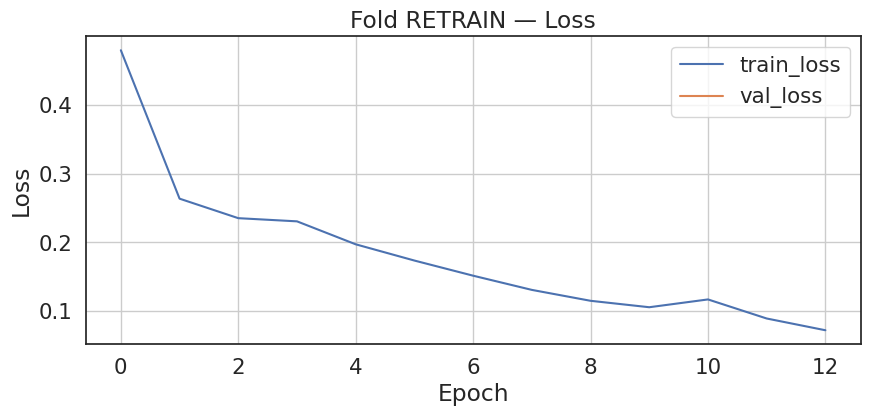

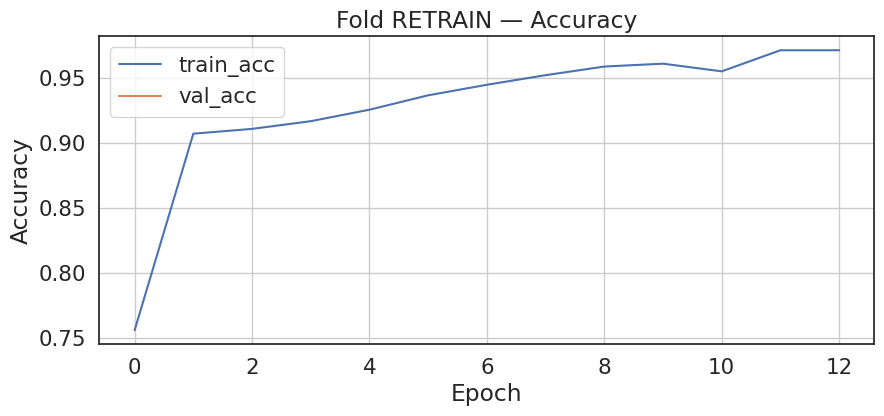

In [ ]:
MODELS_DIR = "/content/drive/MyDrive/PROGETTO AI/TASK2_NEW/TASK2_MODELS_CLS"

run_name="VGG_16_finetuning3_equal_F1_retrain"

model_cfg = {
  "arch": "vgg16_3ch",
  "channels_number": 3,
  "classes": 2,
  "model_cfg": {
      "dropout": 0.5,
      "unfreeze_last_block": True
  },
  "class_weights": None,
  "min_lr": 1e-9,
}

run_dir = os.path.join(MODELS_DIR, run_name)
os.makedirs(run_dir, exist_ok=True)

BATCH_SIZE = 16
NUM_WORKERS = 2


N_EPOCHS = 13
LR = 5e-5
WEIGHT_DECAY = 1e-3
PATIENCE = 0
SEED = 42

metrics = run_retrain_cls_f1(
    X_all=X_cls,
    y_all=y_cls,
    filenames_all=fnames_orig,
    device=device,
    MODELS_DIR=MODELS_DIR,
    run_name=run_name,
    model_cfg=model_cfg,
    holdout_size=0,
    n_epochs=N_EPOCHS,
    patience=PATIENCE,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    seed=SEED,
    class_priority=[1, 0],
    ignore_class=2,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    class_names=["Benign", "Malignant"],
    plot_curves=True
)

